In [23]:
import os
import time
import logging
from pathlib import Path
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import wfdb
import neurokit2 as nk
from scipy.signal import resample_poly
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, confusion_matrix,
    f1_score, roc_curve, precision_recall_curve,
)
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["figure.figsize"] = (12, 5)

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
logger = logging.getLogger("chagas")

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"PyTorch {torch.__version__}")
    print(f"Device : {device} ({torch.cuda.get_device_name(0)})")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"PyTorch {torch.__version__}")
    print(f"Device : {device} (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"PyTorch {torch.__version__}")
    print(f"Device : {device}")

PyTorch 2.10.0
Device : mps (Apple Silicon GPU)


In [24]:

CFG = {
    "code15_dir":    "4916206",
    "samitrop_dir":  "sami-trop",
    "ptbxl_dir":     "ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3",
    
    "exclude_ptbxl": True,
    
    "val_fraction":   0.15,
    "test_fraction":  0.15,
    "random_seed":    42,
    
    "neg_to_pos_ratio": 5,
    "preprocessed_cache": "preprocessed_cache_brazil.h5",

    "target_fs":          500,
    "target_duration_s":  10,
    "cleaning_method":    "neurokit",
    "hdf5_fs":            400,

    "in_channels":          12,
    "base_filters":         64,
    "num_blocks_per_group": 2,
    "kernel_size":          7,
    "dropout":              0.3,

    "epochs":       50,
    "batch_size":   32,
    "lr":           1e-3,
    "weight_decay": 1e-4,
    "patience":     10,
    "num_workers":  0,

    "loss_fn":            "focal",
    "pos_weight":         10.0,
    "focal_alpha":        0.25,
    "focal_gamma":        2.0,
    "label_smoothing":    0.1,

    "use_weighted_sampler": False,

    "seeds":        [42, 123, 2025],

    "checkpoint_dir": "checkpoints",
}

SEQ_LEN = int(CFG["target_fs"] * CFG["target_duration_s"])
print(f"Sequence length: {SEQ_LEN} samples  ({CFG['target_duration_s']}s @ {CFG['target_fs']}Hz)")

Sequence length: 5000 samples  (10s @ 500Hz)


In [25]:

def load_code15_metadata(code15_dir: str) -> pd.DataFrame:
    """Load CODE-15% metadata with Chagas labels."""
    exams_df = pd.read_csv(os.path.join(code15_dir, "exams.csv"))
    labels_df = pd.read_csv(os.path.join(code15_dir, "code15_chagas_labels.csv"))
    
    df = exams_df.merge(labels_df[["exam_id", "chagas"]], on="exam_id", how="inner")
    df["source"] = "code15"
    df["chagas"] = df["chagas"].astype(int)
    df["sex"] = df["is_male"].map({True: 1, False: 0})
    
    logger.info(f"CODE-15%: {len(df)} records, {df['chagas'].sum()} Chagas+ ({100*df['chagas'].mean():.2f}%)")
    return df[["exam_id", "age", "sex", "chagas", "source", "trace_file"]]

def load_samitrop_metadata(samitrop_dir: str) -> pd.DataFrame:
    """Load SaMi-Trop metadata (all Chagas positive)."""
    df = pd.read_csv(os.path.join(samitrop_dir, "exams.csv"))
    df["source"] = "samitrop"
    df["chagas"] = 1
    df["sex"] = df["is_male"].map({True: 1, False: 0})
    df["trace_file"] = "exams.hdf5"
    
    logger.info(f"SaMi-Trop: {len(df)} records, {df['chagas'].sum()} Chagas+ (100%)")
    return df[["exam_id", "age", "sex", "chagas", "source", "trace_file"]]

def load_ptbxl_metadata(ptbxl_dir: str) -> pd.DataFrame:
    """Load PTB-XL metadata (all Chagas negative)."""
    df = pd.read_csv(os.path.join(ptbxl_dir, "ptbxl_database.csv"))
    df["source"] = "ptbxl"
    df["chagas"] = 0
    df["exam_id"] = df["ecg_id"]
    df["sex"] = df["sex"].map({1: 1, 0: 0})
    df["trace_file"] = df["filename_hr"]
    
    logger.info(f"PTB-XL: {len(df)} records, 0 Chagas+ (0%)")
    return df[["exam_id", "age", "sex", "chagas", "source", "trace_file"]]

def create_unified_metadata(cfg: dict) -> pd.DataFrame:
    """Combine datasets into unified metadata.
    
    If cfg["exclude_ptbxl"] is True, only Brazilian data (CODE-15% + SaMi-Trop) is loaded.
    This avoids domain contamination from German PTB-XL data.
    """
    dfs = []
    
    if Path(cfg["code15_dir"]).exists():
        dfs.append(load_code15_metadata(cfg["code15_dir"]))
    else:
        logger.warning(f"CODE-15% directory not found: {cfg['code15_dir']}")
    
    if Path(cfg["samitrop_dir"]).exists():
        dfs.append(load_samitrop_metadata(cfg["samitrop_dir"]))
    else:
        logger.warning(f"SaMi-Trop directory not found: {cfg['samitrop_dir']}")
    
    if cfg.get("exclude_ptbxl", False):
        logger.info("PTB-XL excluded: training on Brazilian data only")
    elif Path(cfg["ptbxl_dir"]).exists():
        dfs.append(load_ptbxl_metadata(cfg["ptbxl_dir"]))
    else:
        logger.warning(f"PTB-XL directory not found: {cfg['ptbxl_dir']}")
    
    if not dfs:
        raise FileNotFoundError("No datasets found! Please check the data paths in CFG.")
    
    unified = pd.concat(dfs, ignore_index=True)
    
    for source in unified["source"].unique():
        n = (unified["source"] == source).sum()
        n_pos = unified[unified["source"] == source]["chagas"].sum()
        logger.info(f"  {source}: {n:,} records ({n_pos:,} Chagas+)")
    
    logger.info(f"TOTAL: {len(unified)} records, {unified['chagas'].sum()} Chagas+ "
                f"({100*unified['chagas'].mean():.2f}%)")
    return unified

metadata = create_unified_metadata(CFG)

if CFG.get("neg_to_pos_ratio") is not None:
    n_pos = metadata["chagas"].sum()
    n_neg_target = int(n_pos * CFG["neg_to_pos_ratio"])
    
    positives = metadata[metadata["chagas"] == 1]
    negatives = metadata[metadata["chagas"] == 0]
    
    if len(negatives) > n_neg_target:
        negatives = negatives.sample(n=n_neg_target, random_state=CFG["random_seed"])
        logger.info(f"Downsampled negatives: {len(metadata[metadata['chagas']==0])} -> {len(negatives)}")
    
    metadata = pd.concat([positives, negatives], ignore_index=True)
    logger.info(f"After downsampling: {len(metadata)} samples "
                f"({metadata['chagas'].sum()} pos, {(metadata['chagas']==0).sum()} neg, "
                f"ratio 1:{CFG['neg_to_pos_ratio']})")

train_val_meta, test_meta = train_test_split(
    metadata,
    test_size=0.15,
    stratify=metadata["chagas"],
    random_state=CFG["random_seed"],
)

train_meta, val_meta = train_test_split(
    train_val_meta,
    test_size=0.18,
    stratify=train_val_meta["chagas"],
    random_state=CFG["random_seed"],
)

train_meta = train_meta.reset_index(drop=True)
val_meta = val_meta.reset_index(drop=True)
test_meta = test_meta.reset_index(drop=True)

print(f"\n{'='*70}")
print(f"  DATASET SPLIT SUMMARY (Train / Val / Test)")
print(f"{'='*70}")
print(f"  Training   : {len(train_meta):>7,} samples  "
      f"({train_meta['chagas'].sum():>5,} Chagas+, {100*train_meta['chagas'].mean():.2f}%)")
print(f"  Validation : {len(val_meta):>7,} samples  "
      f"({val_meta['chagas'].sum():>5,} Chagas+, {100*val_meta['chagas'].mean():.2f}%)")
print(f"  Test       : {len(test_meta):>7,} samples  "
      f"({test_meta['chagas'].sum():>5,} Chagas+, {100*test_meta['chagas'].mean():.2f}%)")
print(f"{'='*70}")

print("\nSamples per source:")
for source in metadata["source"].unique():
    train_n = (train_meta["source"] == source).sum()
    val_n = (val_meta["source"] == source).sum()
    test_n = (test_meta["source"] == source).sum()
    pos_train = train_meta[train_meta["source"] == source]["chagas"].sum()
    print(f"  {source:10}: train={train_n:>6,} ({pos_train:>4,}+), val={val_n:>5,}, test={test_n:>5,}")

if CFG.get("exclude_ptbxl", False):
    print("\nPTB-XL excluded: training on Brazilian data only")

15:10:37 [INFO] CODE-15%: 343424 records, 6561 Chagas+ (1.91%)
15:10:37 [INFO] SaMi-Trop: 1631 records, 1631 Chagas+ (100%)
15:10:37 [INFO] ⚠️  APPROACH 3: PTB-XL EXCLUDED — Training on Brazilian data only
15:10:37 [INFO]   → code15: 343,424 records (6,561 Chagas+)
15:10:37 [INFO]   → samitrop: 1,631 records (1,631 Chagas+)
15:10:37 [INFO] TOTAL: 345055 records, 8192 Chagas+ (2.37%)
15:10:37 [INFO] Downsampled negatives: 336863 → 40960
15:10:37 [INFO] After downsampling: 49152 samples (8192 pos, 40960 neg, ratio 1:5)



  DATASET SPLIT SUMMARY (Train / Val / Test)
  Training   :  34,258 samples  (5,710 Chagas+, 16.67%)
  Validation :   7,521 samples  (1,253 Chagas+, 16.66%)
  Test       :   7,373 samples  (1,229 Chagas+, 16.67%)

Samples per source:
  code15    : train=33,128 (4,580+), val=7,268, test=7,125
  samitrop  : train= 1,130 (1,130+), val=  253, test=  248

⚠️  PTB-XL EXCLUDED — Training on Brazilian data only (Approach 3)


In [26]:

def find_records(data_dir: str) -> list:
    """Return a sorted list of record paths (no extension) under *data_dir*."""
    data_dir = Path(data_dir)
    records = []
    for root, _, files in os.walk(data_dir):
        for f in files:
            if f.endswith(".hea"):
                rel = os.path.relpath(os.path.join(root, f[:-4]), data_dir)
                records.append(rel)
    records.sort()
    return records

def load_record(data_dir: str, record_name: str):
    """Load a single WFDB record. Returns (signal [n_samples, n_leads], meta dict)."""
    rec = wfdb.rdrecord(os.path.join(data_dir, record_name))
    signal = rec.p_signal
    fs = rec.fs
    meta = {
        "fs": fs,
        "age": _extract_age(rec),
        "sex": _extract_sex(rec),
        "chagas": _extract_label(rec),
    }
    return signal, meta

def _extract_age(rec) -> float:
    for c in (rec.comments or []):
        lo = c.lower()
        if "age" in lo:
            parts = lo.split(":")
            if len(parts) >= 2:
                try:
                    return float(parts[-1].strip())
                except ValueError:
                    pass
    return float("nan")

def _extract_sex(rec) -> int:
    for c in (rec.comments or []):
        lo = c.lower()
        if "sex" in lo:
            if "male" in lo and "female" not in lo:
                return 1
            if "female" in lo:
                return 0
    return -1

def _extract_label(rec) -> int:
    """1 = Chagas+, 0 = Chagas−, −1 = unknown."""
    for c in (rec.comments or []):
        lo = c.lower().strip()
        if lo.startswith("#chagas") or lo.startswith("chagas"):
            parts = lo.split(":")
            if len(parts) >= 2:
                val = parts[-1].strip()
                if val in ("true", "1", "yes"):
                    return 1
                if val in ("false", "0", "no"):
                    return 0
        if ("labels" in lo or "dx" in lo) and "chagas" in lo:
            return 1
    return -1

In [27]:

def clean_ecg_lead(lead_signal: np.ndarray, fs: int, method: str = "neurokit") -> np.ndarray:
    """Clean a single ECG lead using NeuroKit2.
    
    Available methods:
        - "neurokit" (default): 0.5 Hz highpass + 50 Hz powerline removal
        - "biosppy": FIR bandpass (3-45 Hz)
        - "pantompkins1985": bandpass as per Pan-Tompkins algorithm
        - "hamilton2002": bandpass as per Hamilton algorithm
        - "elgendi2010": bandpass (0.5-100 Hz) as per Elgendi
        - "engzeemod2012": bandpass (52-48 Hz)
    """
    try:
        cleaned = nk.ecg_clean(lead_signal, sampling_rate=int(fs), method=method)
        return cleaned.astype(np.float32)
    except Exception as e:
        logger.warning(f"ECG cleaning failed: {e}. Using original signal.")
        return lead_signal.astype(np.float32)

def clean_ecg_multilead(signal: np.ndarray, fs: int, method: str = "neurokit") -> np.ndarray:
    """Clean multi-lead ECG signal (n_samples, n_leads) using NeuroKit2.
    
    Applies ecg_clean() to each lead independently.
    """
    n_samples, n_leads = signal.shape
    cleaned = np.zeros_like(signal, dtype=np.float32)
    for i in range(n_leads):
        cleaned[:, i] = clean_ecg_lead(signal[:, i], fs, method=method)
    return cleaned

def resample_signal(signal: np.ndarray, fs_orig: float, fs_target: float) -> np.ndarray:
    """Resample signal to target sampling rate using polyphase filtering."""
    if fs_orig == fs_target:
        return signal.astype(np.float32)
    from math import gcd
    up, down = int(fs_target), int(fs_orig)
    d = gcd(up, down)
    return resample_poly(signal, up // d, down // d, axis=0).astype(np.float32)

def pad_or_truncate(signal: np.ndarray, target_length: int) -> np.ndarray:
    """Pad with zeros or truncate signal to target length."""
    n = signal.shape[0]
    if n >= target_length:
        return signal[:target_length]
    pad_width = [(0, target_length - n)] + [(0, 0)] * (signal.ndim - 1)
    return np.pad(signal, pad_width, mode="constant", constant_values=0.0)

def normalize_signal(signal: np.ndarray) -> np.ndarray:
    """Per-lead zero-mean, unit-variance normalisation."""
    mean = signal.mean(axis=0, keepdims=True)
    std = signal.std(axis=0, keepdims=True)
    std = np.where(std == 0, 1.0, std)
    return ((signal - mean) / std).astype(np.float32)

def compute_signal_quality(signal: np.ndarray, fs: int) -> np.ndarray:
    """Compute signal quality index for each lead using NeuroKit2.
    
    Returns array of quality scores (0-1) for each lead.
    Higher values indicate better signal quality.
    """
    n_leads = signal.shape[1]
    quality_scores = np.zeros(n_leads)
    for i in range(n_leads):
        try:
            quality = nk.ecg_quality(signal[:, i], sampling_rate=int(fs), method="zhao2018")
            quality_scores[i] = np.mean(quality) if hasattr(quality, '__len__') else quality
        except Exception:
            quality_scores[i] = np.nan
    return quality_scores

def preprocess_ecg(signal: np.ndarray, fs: float, target_fs: float = 500.0,
                   target_duration_s: float = 10.0, cleaning_method: str = "neurokit",
                   filter_low: float = None, filter_high: float = None) -> np.ndarray:
    """Full ECG preprocessing pipeline using NeuroKit2.
    
    Pipeline:
        1. Clean ECG using NeuroKit2 (validated filtering)
        2. Resample to target sampling rate
        3. Pad or truncate to target duration
        4. Normalise each lead (zero-mean, unit-variance)
    
    Args:
        signal: Raw ECG signal (n_samples, n_leads)
        fs: Original sampling rate (Hz)
        target_fs: Target sampling rate (Hz)
        target_duration_s: Target duration in seconds
        cleaning_method: NeuroKit2 cleaning method (default: "neurokit")
        filter_low: Unused, kept for backwards compatibility
        filter_high: Unused, kept for backwards compatibility
    
    Returns:
        Preprocessed signal (target_samples, n_leads)
    """
    signal = clean_ecg_multilead(signal, int(fs), method=cleaning_method)
    
    signal = resample_signal(signal, fs, target_fs)
    
    target_len = int(target_fs * target_duration_s)
    signal = pad_or_truncate(signal, target_len)
    
    signal = normalize_signal(signal)
    
    return signal

print(f"NeuroKit2 version: {nk.__version__}")
print("Available ECG cleaning methods: neurokit, biosppy, pantompkins1985, hamilton2002, elgendi2010")

NeuroKit2 version: 0.2.13
Available ECG cleaning methods: neurokit, biosppy, pantompkins1985, hamilton2002, elgendi2010


In [28]:

class HDF5Cache:
    """Cache for HDF5 file handles to avoid repeated open/close."""
    
    def __init__(self):
        self._cache = {}
        self._exam_id_to_idx = {}
    
    def get_file(self, path: str):
        if path not in self._cache:
            self._cache[path] = h5py.File(path, "r")
        return self._cache[path]
    
    def build_index(self, hdf5_path: str):
        """Build exam_id -> index mapping for an HDF5 file."""
        if hdf5_path in self._exam_id_to_idx:
            return
        f = self.get_file(hdf5_path)
        if "exam_id" in f:
            exam_ids = f["exam_id"][:]
            for i, eid in enumerate(exam_ids):
                self._exam_id_to_idx[(hdf5_path, int(eid))] = i
    
    def get_index(self, hdf5_path: str, exam_id: int) -> int:
        """Get the index of an exam_id in an HDF5 file."""
        key = (hdf5_path, exam_id)
        if key not in self._exam_id_to_idx:
            self.build_index(hdf5_path)
        return self._exam_id_to_idx.get(key)
    
    def close_all(self):
        for f in self._cache.values():
            f.close()
        self._cache.clear()

_hdf5_cache = HDF5Cache()

def load_hdf5_signal(source: str, exam_id: int, trace_file: str, cfg: dict) -> Tuple[np.ndarray, int]:
    """Load ECG signal from HDF5 file.
    
    Returns:
        signal: (n_samples, 12) array
        fs: sampling rate (Hz)
    """
    if source == "code15":
        hdf5_path = os.path.join(cfg["code15_dir"], trace_file)
        f = _hdf5_cache.get_file(hdf5_path)
        idx = _hdf5_cache.get_index(hdf5_path, exam_id)
        if idx is None:
            raise ValueError(f"exam_id {exam_id} not found in {hdf5_path}")
        signal = f["tracings"][idx]
        
    elif source == "samitrop":
        hdf5_path = os.path.join(cfg["samitrop_dir"], trace_file)
        f = _hdf5_cache.get_file(hdf5_path)
        samitrop_df = pd.read_csv(os.path.join(cfg["samitrop_dir"], "exams.csv"))
        idx = samitrop_df[samitrop_df["exam_id"] == exam_id].index
        if len(idx) == 0:
            raise ValueError(f"exam_id {exam_id} not found in SaMi-Trop")
        signal = f["tracings"][idx[0]]
    else:
        raise ValueError(f"Unknown source: {source}")
    
    return np.array(signal, dtype=np.float32), cfg["hdf5_fs"]

def load_ptbxl_signal(trace_file: str, cfg: dict) -> Tuple[np.ndarray, int]:
    """Load ECG signal from PTB-XL WFDB file.
    
    Returns:
        signal: (n_samples, 12) array
        fs: sampling rate (Hz)
    """
    record_path = os.path.join(cfg["ptbxl_dir"], trace_file)
    rec = wfdb.rdrecord(record_path)
    return rec.p_signal.astype(np.float32), int(rec.fs)

class ChagasECGDataset(Dataset):
    """Multi-source ECG dataset for Chagas detection.
    
    Supports loading from:
        - CODE-15% (HDF5)
        - SaMi-Trop (HDF5)
        - PTB-XL (WFDB)
    
    Each item returns:
        signal : Tensor (12, 5000), leads-first, 10s @ 500Hz
        label  : Tensor scalar, 0 or 1
    
    Preprocessing is performed using NeuroKit2 (Makowski et al., 2021).
    """

    def __init__(self, metadata: pd.DataFrame, cfg: dict, transform=None):
        """
        Args:
            metadata: DataFrame with columns [exam_id, age, sex, chagas, source, trace_file]
            cfg: Configuration dictionary
            transform: Optional transform to apply to signals
        """
        self.metadata = metadata.reset_index(drop=True)
        self.cfg = cfg
        self.transform = transform
        
        self.labels = self.metadata["chagas"].values.astype(int)
        self.ages = self.metadata["age"].values
        self.sexes = self.metadata["sex"].values
        
        n_pos = self.labels.sum()
        logger.info(f"Dataset created: {len(self)} samples (pos={n_pos}, neg={len(self)-n_pos}, "
                    f"prev={100*n_pos/len(self):.2f}%)")

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        source = row["source"]
        exam_id = int(row["exam_id"])
        trace_file = row["trace_file"]
        
        if source in ("code15", "samitrop"):
            signal, fs = load_hdf5_signal(source, exam_id, trace_file, self.cfg)
        elif source == "ptbxl":
            signal, fs = load_ptbxl_signal(trace_file, self.cfg)
        else:
            raise ValueError(f"Unknown source: {source}")
        
        signal = preprocess_ecg(
            signal, 
            fs=fs,
            target_fs=self.cfg["target_fs"],
            target_duration_s=self.cfg["target_duration_s"],
            cleaning_method=self.cfg["cleaning_method"],
        )
        
        signal = torch.from_numpy(signal.T).float()
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        
        if self.transform is not None:
            signal = self.transform(signal)
        
        return signal, label

def build_weighted_sampler(dataset: ChagasECGDataset):
    """Oversample minority class during training."""
    if len(dataset) == 0:
        logger.error("Cannot build weighted sampler: dataset is empty!")
        raise ValueError("Dataset is empty. Cannot proceed without data.")
    
    labels = dataset.labels
    class_counts = np.bincount(labels, minlength=2)
    
    class_counts = np.where(class_counts == 0, 1, class_counts)
    weights_per_class = 1.0 / class_counts
    sample_weights = weights_per_class[labels]
    
    return WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).double(),
        num_samples=len(dataset),
        replacement=True,
    )

In [29]:

def build_preprocessing_cache(metadata: pd.DataFrame, cfg: dict, cache_path: str):
    """Pre-process all ECGs and save to HDF5 cache."""
    cache_path = Path(cache_path)
    
    if cache_path.exists():
        logger.info(f"Cache already exists: {cache_path}")
        return
    
    logger.info(f"Building preprocessing cache for {len(metadata)} samples...")
    
    target_len = int(cfg["target_fs"] * cfg["target_duration_s"])
    
    with h5py.File(cache_path, "w") as cache:
        cache.create_dataset("signals", shape=(len(metadata), 12, target_len), dtype=np.float32)
        cache.create_dataset("labels", shape=(len(metadata),), dtype=np.int8)
        cache.create_dataset("exam_ids", shape=(len(metadata),), dtype=np.int64)
        
        for i, (_, row) in enumerate(tqdm(metadata.iterrows(), total=len(metadata), 
                                          desc="Preprocessing ECGs")):
            try:
                source = row["source"]
                exam_id = int(row["exam_id"])
                trace_file = row["trace_file"]
                
                if source in ("code15", "samitrop"):
                    signal, fs = load_hdf5_signal(source, exam_id, trace_file, cfg)
                elif source == "ptbxl":
                    signal, fs = load_ptbxl_signal(trace_file, cfg)
                else:
                    raise ValueError(f"Unknown source: {source}")
                
                signal = preprocess_ecg(
                    signal, fs=fs,
                    target_fs=cfg["target_fs"],
                    target_duration_s=cfg["target_duration_s"],
                    cleaning_method=cfg["cleaning_method"],
                )
                
                cache["signals"][i] = signal.T
                cache["labels"][i] = int(row["chagas"])
                cache["exam_ids"][i] = exam_id
                
            except Exception as e:
                logger.warning(f"Failed to process {row['source']}/{exam_id}: {e}")
                cache["signals"][i] = np.zeros((12, target_len), dtype=np.float32)
                cache["labels"][i] = int(row["chagas"])
                cache["exam_ids"][i] = exam_id
    
    cache_size_mb = cache_path.stat().st_size / (1024 * 1024)
    logger.info(f"Cache saved: {cache_path} ({cache_size_mb:.1f} MB)")

class CachedChagasDataset(Dataset):
    """Ultra-fast dataset that reads from preprocessed cache."""
    
    def __init__(self, cache_path: str, indices: np.ndarray, transform=None):
        self.cache_path = cache_path
        self.indices = indices
        self.transform = transform
        
        self.cache = h5py.File(cache_path, "r")
        self.signals = self.cache["signals"]
        self._all_labels = self.cache["labels"][:]
        
        self.labels = self._all_labels[indices]
        
    def __len__(self):
        return len(self.indices)
    
    def __getitem__(self, idx):
        cache_idx = self.indices[idx]
        signal = torch.from_numpy(self.signals[cache_idx][:]).float()
        label = torch.tensor(self._all_labels[cache_idx], dtype=torch.float32)
        
        if self.transform is not None:
            signal = self.transform(signal)
        
        return signal, label
    
    def close(self):
        self.cache.close()

cache_file = CFG["preprocessed_cache"]

all_metadata = pd.concat([train_meta, val_meta, test_meta], ignore_index=True)

build_preprocessing_cache(all_metadata, CFG, cache_file)

train_indices = np.arange(len(train_meta))
val_indices = np.arange(len(train_meta), len(train_meta) + len(val_meta))
test_indices = np.arange(len(train_meta) + len(val_meta), len(all_metadata))

print(f"\nPreprocessing cache ready")
print(f"  Cache file: {cache_file}")
print(f"  Train indices: 0 to {len(train_meta)-1} ({len(train_indices)} samples)")
print(f"  Val indices: {len(train_meta)} to {len(train_meta)+len(val_meta)-1} ({len(val_indices)} samples)")
print(f"  Test indices: {len(train_meta)+len(val_meta)} to {len(all_metadata)-1} ({len(test_indices)} samples)")

15:10:37 [INFO] Cache already exists: preprocessed_cache_brazil.h5



✓ Preprocessing cache ready!
  Cache file: preprocessed_cache_brazil.h5
  Train indices: 0 to 34257 (34258 samples)
  Val indices: 34258 to 41778 (7521 samples)
  Test indices: 41779 to 49151 (7373 samples)


In [30]:

train_ds = CachedChagasDataset(cache_file, train_indices)
val_ds = CachedChagasDataset(cache_file, val_indices)

train_labels = train_ds.labels
class_counts = np.bincount(train_labels.astype(int), minlength=2)
class_counts = np.where(class_counts == 0, 1, class_counts)

train_sampler = None
if CFG.get("use_weighted_sampler", True):
    weights_per_class = 1.0 / class_counts
    sample_weights = weights_per_class[train_labels.astype(int)]
    train_sampler = WeightedRandomSampler(
        weights=torch.from_numpy(sample_weights).double(),
        num_samples=len(train_ds),
        replacement=True,
    )
    print("WeightedRandomSampler: ENABLED")
else:
    print("WeightedRandomSampler: DISABLED (Focal Loss handles imbalance)")

use_pin_memory = device.type == "cuda"

train_loader = DataLoader(
    train_ds, batch_size=CFG["batch_size"],
    sampler=train_sampler, shuffle=(train_sampler is None),
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory, drop_last=True,
)
val_loader = DataLoader(
    val_ds, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory,
)

print(f"\nTrain: {len(train_ds):,} samples  ({len(train_loader):,} batches)")
print(f"Val  : {len(val_ds):,} samples  ({len(val_loader):,} batches)")
print(f"Class balance: {class_counts[0]:,} neg / {class_counts[1]:,} pos")

WeightedRandomSampler: DISABLED (Focal Loss handles imbalance)

Train: 34,258 samples  (1,070 batches)
Val  : 7,521 samples  (236 batches)
Class balance: 28,548 neg / 5,710 pos


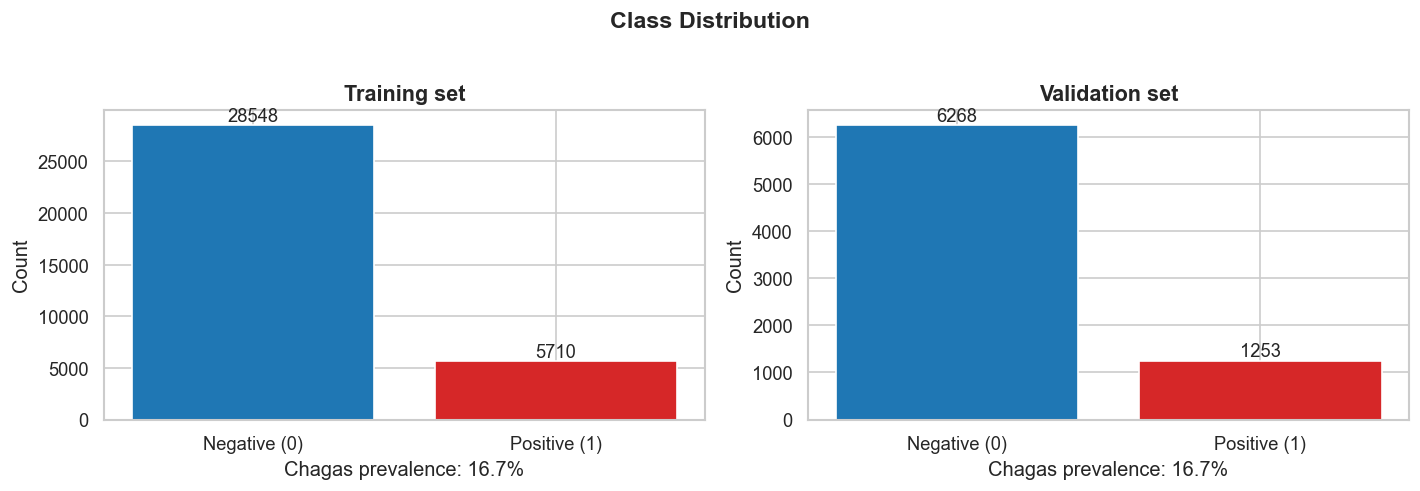

In [31]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, ds, title in [(axes[0], train_ds, "Training set"),
                       (axes[1], val_ds, "Validation set")]:
    labels = np.array(ds.labels)
    counts = np.bincount(labels.astype(int), minlength=2)
    bars = ax.bar(["Negative (0)", "Positive (1)"], counts,
                  color=[sns.color_palette()[0], sns.color_palette()[3]])
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("Count")
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                str(c), ha="center", va="bottom", fontsize=11)
    prev = 100 * counts[1] / counts.sum()
    ax.set_xlabel(f"Chagas prevalence: {prev:.1f}%")

fig.suptitle("Class Distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

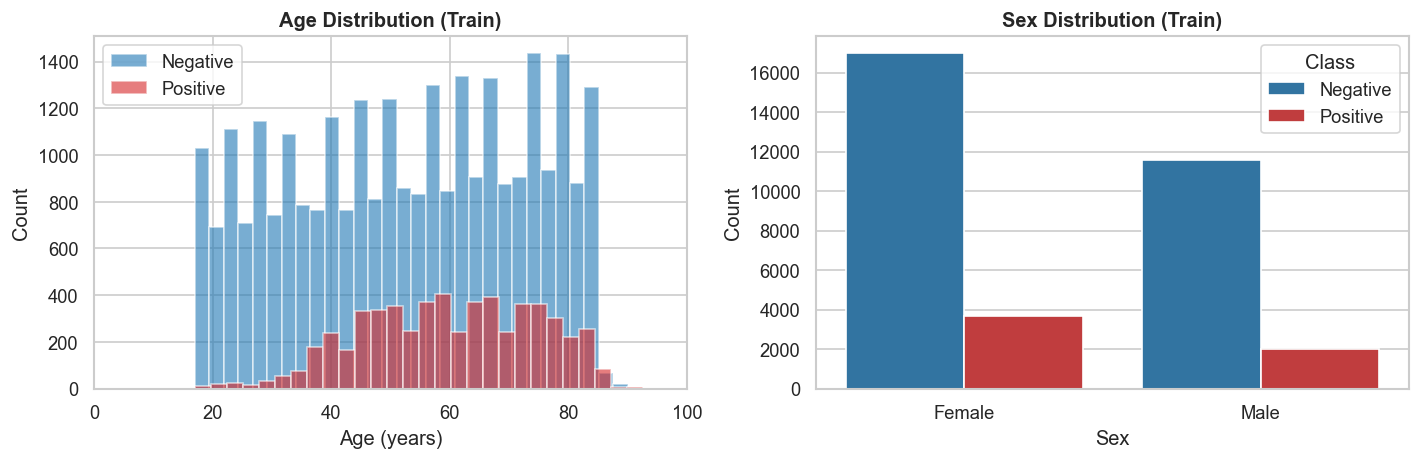

In [32]:

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ages = train_meta["age"].values
labels_arr = train_meta["chagas"].values
valid_ages = ~np.isnan(ages)

axes[0].hist(ages[(labels_arr == 0) & valid_ages], bins=30, alpha=0.6,
             label="Negative", color=sns.color_palette()[0])
axes[0].hist(ages[(labels_arr == 1) & valid_ages], bins=30, alpha=0.6,
             label="Positive", color=sns.color_palette()[3])
axes[0].set_xlabel("Age (years)")
axes[0].set_ylabel("Count")
axes[0].set_title("Age Distribution (Train)", fontweight="bold")
axes[0].set_xlim(0, 100)
axes[0].legend()

sexes = train_meta["sex"].values
sex_labels = {0: "Female", 1: "Male", -1: "Unknown"}
sex_data = []
for lbl in [0, 1]:
    for s in [0, 1, -1]:
        count = ((labels_arr == lbl) & (sexes == s)).sum()
        if count > 0:
            sex_data.append({"Class": ["Negative", "Positive"][lbl],
                             "Sex": sex_labels[s], "Count": int(count)})
if sex_data:
    sex_df = pd.DataFrame(sex_data)
    sns.barplot(data=sex_df, x="Sex", y="Count", hue="Class",
                palette=[sns.color_palette()[0], sns.color_palette()[3]],
                ax=axes[1])
axes[1].set_title("Sex Distribution (Train)", fontweight="bold")

plt.tight_layout()
plt.show()

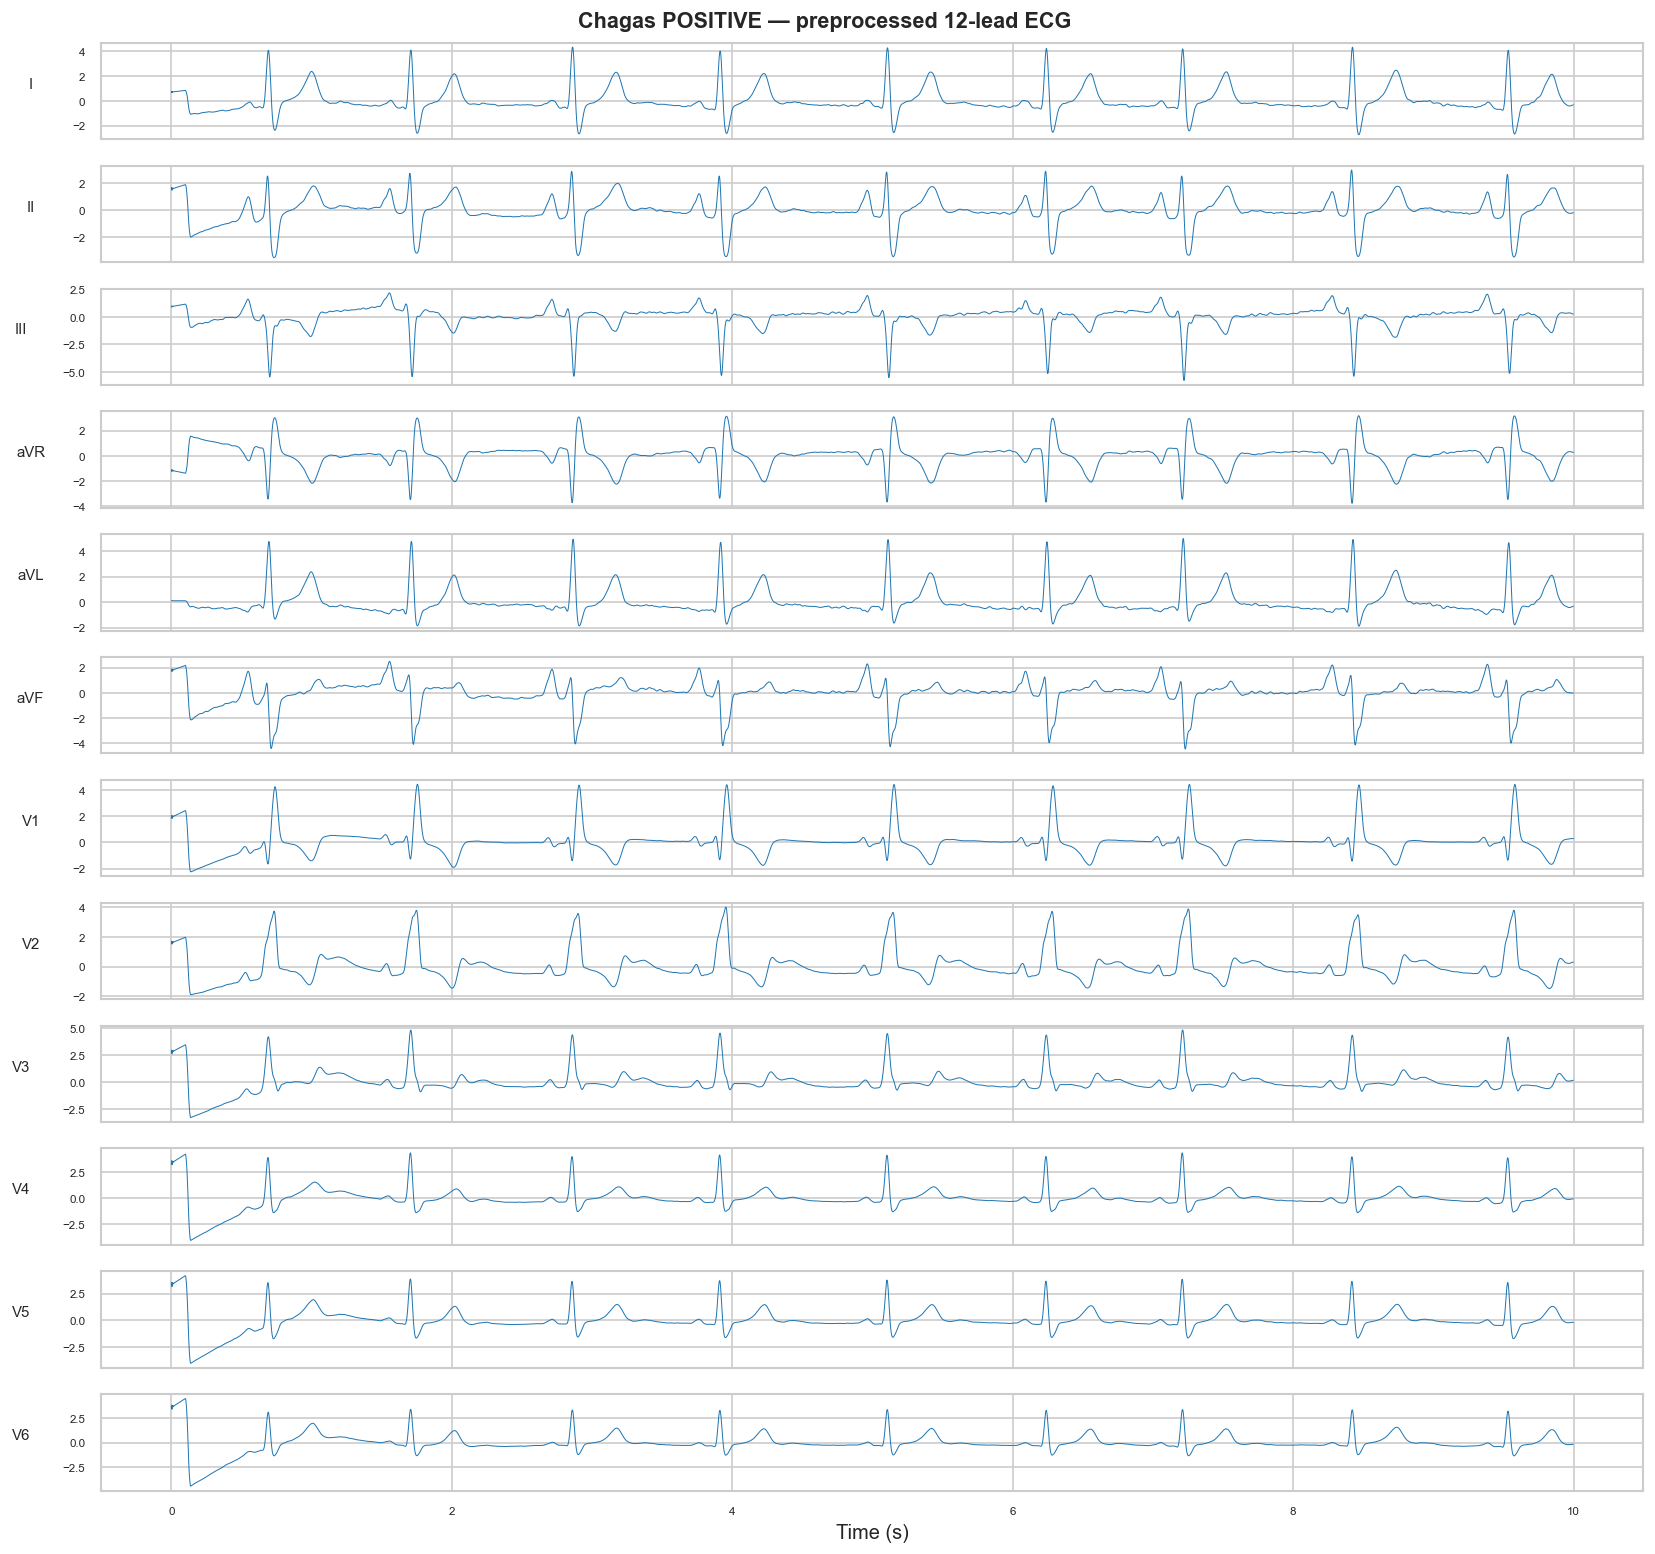

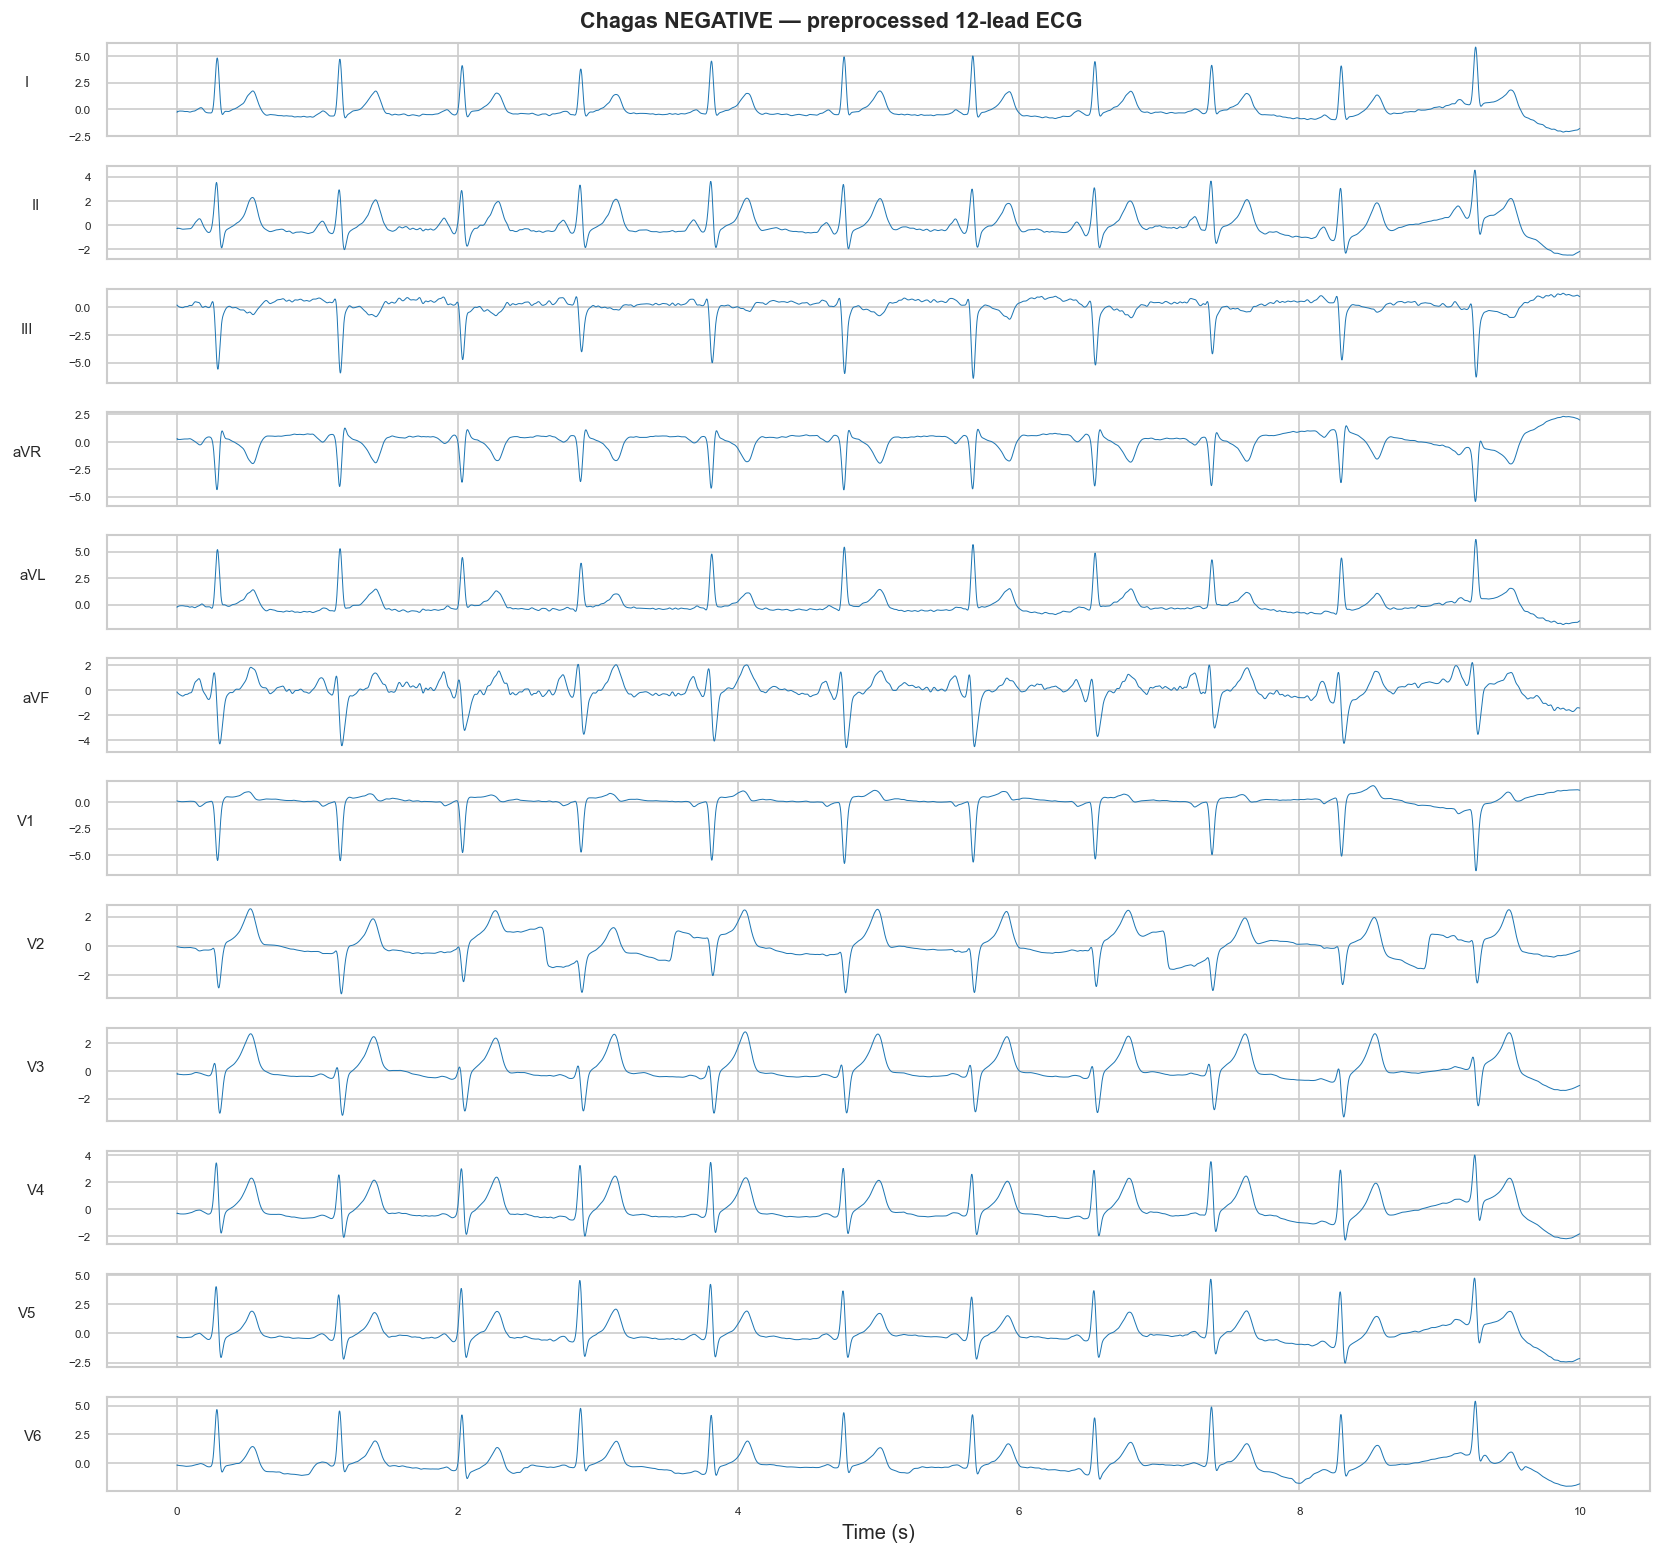

In [33]:

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]

def plot_ecg(signal_tensor, title, n_leads=12, fs=500):
    """Plot all leads of a preprocessed ECG tensor (leads, samples)."""
    fig, axes = plt.subplots(n_leads, 1, figsize=(14, n_leads * 1.1), sharex=True)
    t = np.arange(signal_tensor.shape[1]) / fs
    for i in range(min(n_leads, signal_tensor.shape[0])):
        axes[i].plot(t, signal_tensor[i].numpy(), linewidth=0.6,
                     color=sns.color_palette()[0])
        axes[i].set_ylabel(LEAD_NAMES[i], rotation=0, labelpad=25, fontsize=9)
        axes[i].tick_params(labelsize=7)
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

pos_idx = next(i for i, l in enumerate(train_ds.labels) if l == 1)
neg_idx = next(i for i, l in enumerate(train_ds.labels) if l == 0)

sig_pos, _ = train_ds[pos_idx]
sig_neg, _ = train_ds[neg_idx]

plot_ecg(sig_pos, "Chagas positive: preprocessed 12-lead ECG")
plot_ecg(sig_neg, "Chagas negative: preprocessed 12-lead ECG")

In [34]:
class ResidualBlock1D(nn.Module):
    """Pre-activation residual block with two conv layers."""

    def __init__(self, in_channels, out_channels, kernel_size=7,
                 stride=1, dropout=0.2):
        super().__init__()
        padding = kernel_size // 2

        self.bn1 = nn.BatchNorm1d(in_channels)
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size,
                               stride=stride, padding=padding, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size,
                               stride=1, padding=padding, bias=False)

        self.skip = nn.Identity()
        if in_channels != out_channels or stride != 1:
            self.skip = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels),
            )

    def forward(self, x):
        residual = self.skip(x)
        out = F.relu(self.bn1(x))
        out = self.conv1(out)
        out = F.relu(self.bn2(out))
        out = self.dropout(out)
        out = self.conv2(out)
        return out + residual

class ECGResNet(nn.Module):
    """1-D ResNet for 12-lead ECG binary classification."""

    def __init__(self, in_channels=12, base_filters=64,
                 num_blocks_per_group=2, kernel_size=7, dropout=0.3):
        super().__init__()

        self.stem = nn.Sequential(
            nn.Conv1d(in_channels, base_filters, kernel_size=15,
                      padding=7, bias=False),
            nn.BatchNorm1d(base_filters),
            nn.ReLU(inplace=True),
        )

        channels = [base_filters, base_filters * 2,
                    base_filters * 4, base_filters * 8]
        self.groups = nn.ModuleList()
        in_ch = base_filters
        for i, out_ch in enumerate(channels):
            blocks = []
            for j in range(num_blocks_per_group):
                stride = 2 if (j == 0 and i > 0) else 1
                blocks.append(ResidualBlock1D(
                    in_ch if j == 0 else out_ch, out_ch,
                    kernel_size=kernel_size, stride=stride, dropout=dropout,
                ))
            self.groups.append(nn.Sequential(*blocks))
            in_ch = out_ch

        self.final_bn = nn.BatchNorm1d(channels[-1])
        self.classifier = nn.Sequential(
            nn.Linear(channels[-1], 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        """x: (batch, 12, seq_len) -> logits: (batch,)"""
        out = self.stem(x)
        for group in self.groups:
            out = group(out)
        out = F.relu(self.final_bn(out))
        out = out.mean(dim=-1)
        return self.classifier(out).squeeze(-1)

In [35]:

model = ECGResNet(
    in_channels=CFG["in_channels"],
    base_filters=CFG["base_filters"],
    num_blocks_per_group=CFG["num_blocks_per_group"],
    kernel_size=CFG["kernel_size"],
    dropout=CFG["dropout"],
).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {n_params:,}")
print(model)

Model parameters: 8,803,329
ECGResNet(
  (stem): Sequential(
    (0): Conv1d(12, 64, kernel_size=(15,), stride=(1,), padding=(7,), bias=False)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (groups): ModuleList(
    (0): Sequential(
      (0): ResidualBlock1D(
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
        (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (dropout): Dropout(p=0.3, inplace=False)
        (conv2): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)
        (skip): Identity()
      )
      (1): ResidualBlock1D(
        (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv1): Conv1d(64, 64, kernel_size=(7,), stride=(1,), padding=(3,), bias=False)

In [36]:

dummy = torch.randn(2, 12, SEQ_LEN, device=device)
with torch.no_grad():
    out = model(dummy)
print(f"Input shape : {dummy.shape}")
print(f"Output shape: {out.shape}")
print(f"Output      : {out}")

Input shape : torch.Size([2, 12, 5000])
Output shape: torch.Size([2])
Output      : tensor([-0.0437, -0.0055], device='mps:0')


In [37]:

class FocalLoss(nn.Module):
    """Focal Loss for binary classification (Lin et al., 2017).
    
    Automatically down-weights easy examples and focuses on hard ones.
    """
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss = alpha_t * (1 - pt) ** self.gamma * bce
        return loss.mean()

class TemperatureScaling(nn.Module):
    """Post-hoc calibration via temperature scaling (Guo et al., 2017).
    
    Learns a single temperature parameter on the validation set
    to calibrate predicted probabilities without retraining.
    """
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, logits):
        return logits / self.temperature

    def fit(self, model, val_loader, device, n_iter=50, lr=0.01):
        """Optimize temperature on validation set using NLL loss."""
        nll = nn.BCEWithLogitsLoss()
        optimizer = torch.optim.LBFGS([self.temperature], lr=lr, max_iter=n_iter)
        
        all_logits, all_labels = [], []
        model.eval()
        with torch.no_grad():
            for signals, labels in val_loader:
                signals = signals.to(device)
                logits = model(signals)
                all_logits.append(logits.cpu())
                all_labels.append(labels)
        
        all_logits = torch.cat(all_logits)
        all_labels = torch.cat(all_labels)
        
        self.to('cpu')
        
        def closure():
            optimizer.zero_grad()
            scaled = self.forward(all_logits)
            loss = nll(scaled, all_labels)
            loss.backward()
            return loss
        
        optimizer.step(closure)
        print(f"Learned temperature: {self.temperature.item():.4f}")
        return self.temperature.item()

def compute_ece(y_true, y_prob, n_bins=15):
    """Expected Calibration Error. Returns a value in [0, 1]; lower is better."""
    y_true = np.asarray(y_true, dtype=float)
    y_prob = np.asarray(y_prob, dtype=float)
    
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob > bin_edges[i]) & (y_prob <= bin_edges[i + 1])
        if mask.sum() == 0:
            continue
        bin_conf = y_prob[mask].mean()
        bin_acc = y_true[mask].mean()
        ece += mask.sum() / len(y_true) * abs(bin_acc - bin_conf)
    return float(ece)

def build_criterion(cfg, device):
    """Build loss function based on configuration."""
    if cfg["loss_fn"] == "focal":
        criterion = FocalLoss(alpha=cfg["focal_alpha"], gamma=cfg["focal_gamma"])
        name = f"FocalLoss (alpha={cfg['focal_alpha']}, gamma={cfg['focal_gamma']})"
    else:
        criterion = nn.BCEWithLogitsLoss(
            pos_weight=torch.tensor([cfg["pos_weight"]], device=device),
        )
        name = f"BCEWithLogitsLoss (pos_weight={cfg['pos_weight']})"
    return criterion.to(device), name

def apply_label_smoothing(labels, epsilon):
    """Apply label smoothing: targets become (1 - epsilon) * target + epsilon * 0.5."""
    if epsilon <= 0.0:
        return labels
    return labels * (1.0 - epsilon) + epsilon * 0.5

✓ FocalLoss, TemperatureScaling, ECE, and helpers defined.


In [38]:
@dataclass
class EvalResult:
    auroc: float
    auprc: float
    challenge_score: float
    f1: float
    sensitivity: float
    specificity: float
    threshold: float

def calculate_tpr_at_capacity(y_true, y_prob, capacity_ratio=0.05):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    n_positives = np.sum(y_true)
    if n_positives == 0: return 0.0
    M = int(np.floor(len(y_true) * capacity_ratio))
    if M == 0: return 0.0
    sorted_indices = np.argsort(y_prob)[::-1]
    top_m_indices = sorted_indices[:M]
    tp_in_top_m = np.sum(y_true[top_m_indices])
    threshold_prob = y_prob[sorted_indices[M-1]]
    patients_at_threshold = np.where(y_prob == threshold_prob)[0]
    included_at_threshold = np.sum(y_prob[top_m_indices] == threshold_prob)
    if len(patients_at_threshold) > included_at_threshold and included_at_threshold > 0:
        tp_above_threshold = np.sum(y_true[y_prob > threshold_prob])
        positives_at_threshold = np.sum(y_true[patients_at_threshold])
        expected_tp_from_ties = positives_at_threshold * (included_at_threshold / len(patients_at_threshold))
        expected_tp = tp_above_threshold + expected_tp_from_ties
        tpr = expected_tp / n_positives
    else:
        tpr = tp_in_top_m / n_positives
    return float(tpr)

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return EvalResult(float("nan"), float("nan"), float("nan"),
                          0.0, 0.0, 0.0, threshold)

    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    challenge_score = calculate_tpr_at_capacity(y_true, y_prob, 0.05)

    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1 = f1_score(y_true, y_pred, zero_division=0.0)

    return EvalResult(auroc, auprc, challenge_score, f1, sens, spec, threshold)

def find_optimal_threshold(y_true, y_prob, metric="f1", n_thresholds=200):
    best_val, best_thr = -1.0, 0.5
    for thr in np.linspace(0.01, 0.99, n_thresholds):
        result = compute_metrics(y_true, y_prob, threshold=thr)
        val = getattr(result, metric, result.f1)
        if val > best_val:
            best_val, best_thr = val, thr
    return float(best_thr)

In [39]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None

    def __call__(self, score):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.counter = 0
            return False
        self.counter += 1
        return self.counter >= self.patience

In [40]:

criterion, loss_name = build_criterion(CFG, device)

optimiser = AdamW(
    model.parameters(),
    lr=CFG["lr"],
    weight_decay=CFG["weight_decay"],
)

scheduler = CosineAnnealingLR(optimiser, T_max=CFG["epochs"])
early_stopping = EarlyStopping(patience=CFG["patience"])

checkpoint_dir = Path(CFG["checkpoint_dir"])
checkpoint_dir.mkdir(parents=True, exist_ok=True)

print(f"Loss       : {loss_name}")
if CFG.get("label_smoothing", 0) > 0:
    print(f"Label smooth: epsilon={CFG['label_smoothing']}")
print(f"Optimiser  : AdamW (lr={CFG['lr']}, wd={CFG['weight_decay']})")
print(f"Scheduler  : CosineAnnealingLR (T_max={CFG['epochs']})")
print(f"Early stop : patience={CFG['patience']}")

Loss       : FocalLoss (alpha=0.25, gamma=2.0)
Label smooth: epsilon=0.1
Optimiser  : AdamW (lr=0.001, wd=0.0001)
Scheduler  : CosineAnnealingLR (T_max=50)
Early stop : patience=10


In [41]:
def train_one_epoch(model, loader, criterion, optimiser, device, epoch=None, total_epochs=None, label_smoothing=0.0):
    model.train()
    running_loss, n = 0.0, 0
    
    desc = f"Epoch {epoch}/{total_epochs} [Train]" if epoch else "Training"
    pbar = tqdm(loader, desc=desc, leave=False)
    
    for signals, labels in pbar:
        signals, labels = signals.to(device), labels.to(device)
        labels = apply_label_smoothing(labels, label_smoothing)
        optimiser.zero_grad()
        logits = model(signals)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        running_loss += loss.item()
        n += 1
        pbar.set_postfix({"loss": f"{running_loss/n:.4f}"})
    
    return running_loss / max(n, 1)

@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    all_labels, all_probs = [], []
    running_loss, n = 0.0, 0
    
    pbar = tqdm(loader, desc="Validating", leave=False)
    
    for signals, labels in pbar:
        signals, labels = signals.to(device), labels.to(device)
        logits = model(signals)
        loss = criterion(logits, labels)
        running_loss += loss.item()
        n += 1
        all_probs.extend(torch.sigmoid(logits).cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().astype(int).tolist())
        pbar.set_postfix({"loss": f"{running_loss/n:.4f}"})
    
    val_loss = running_loss / max(n, 1)
    result = compute_metrics(np.array(all_labels), np.array(all_probs))
    return result, val_loss, np.array(all_labels), np.array(all_probs)

In [42]:

history = []
best_score = -1.0

print(f"{'Epoch':>5} | {'TrainLoss':>9} | {'ValLoss':>8} | "
      f"{'AUROC':>6} | {'AUPRC':>6} | {'CS':>6} | "
      f"{'F1':>6} | {'Sens':>6} | {'Spec':>6} | {'LR':>9} | {'Time':>5}")
print("-" * 105)

for epoch in range(1, CFG["epochs"] + 1):
    t0 = time.time()

    train_loss = train_one_epoch(model, train_loader, criterion, optimiser, device,
                                  epoch=epoch, total_epochs=CFG["epochs"],
                                  label_smoothing=CFG.get("label_smoothing", 0.0))
    val_result, val_loss, val_labels, val_probs = validate(
        model, val_loader, criterion, device)

    elapsed = time.time() - t0
    lr = optimiser.param_groups[0]["lr"]

    record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "auroc": val_result.auroc,
        "auprc": val_result.auprc,
        "challenge_score": val_result.challenge_score,
        "f1": val_result.f1,
        "sensitivity": val_result.sensitivity,
        "specificity": val_result.specificity,
        "lr": lr,
        "time_s": elapsed,
    }
    history.append(record)

    marker = ""
    if val_result.challenge_score > best_score:
        best_score = val_result.challenge_score
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimiser_state_dict": optimiser.state_dict(),
            "challenge_score": best_score,
            "auroc": val_result.auroc,
            "auprc": val_result.auprc,
        }, checkpoint_dir / "best_model.pt")
        marker = " *"

    print(f"{epoch:5d} | {train_loss:9.4f} | {val_loss:8.4f} | "
          f"{val_result.auroc:6.4f} | {val_result.auprc:6.4f} | "
          f"{val_result.challenge_score:6.4f} | {val_result.f1:6.4f} | "
          f"{val_result.sensitivity:6.4f} | {val_result.specificity:6.4f} | "
          f"{lr:9.2e} | {elapsed:5.1f}s{marker}")

    scheduler.step()

    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimiser_state_dict": optimiser.state_dict(),
        "challenge_score": val_result.challenge_score,
    }, checkpoint_dir / f"model_epoch_{epoch}.pt")

    if early_stopping(val_result.challenge_score):
        print(f"\nEarly stopping at epoch {epoch}")
        break

print(f"\nBest Challenge Score: {best_score:.4f}")

Epoch | TrainLoss |  ValLoss |  AUROC |  AUPRC |     CS |     F1 |   Sens |   Spec |        LR |  Time
---------------------------------------------------------------------------------------------------------


    1 |    0.0459 |   0.0384 | 0.7468 | 0.4113 | 0.1907 | 0.0000 | 0.0000 | 1.0000 |  1.00e-03 | 399.5s *


    2 |    0.0446 |   0.0383 | 0.7744 | 0.4403 | 0.1875 | 0.0000 | 0.0000 | 1.0000 |  9.99e-04 | 542.0s


    3 |    0.0436 |   0.0392 | 0.7460 | 0.4114 | 0.1907 | 0.0000 | 0.0000 | 1.0000 |  9.96e-04 | 682.9s


    4 |    0.0436 |   0.0364 | 0.7900 | 0.4652 | 0.1963 | 0.0000 | 0.0000 | 1.0000 |  9.91e-04 | 702.6s *


...

   25 |    0.0403 |   0.0360 | 0.8134 | 0.5374 | 0.2227 | 0.0344 | 0.0176 | 0.9995 |  5.31e-04 | 375.2s


   26 |    0.0403 |   0.0347 | 0.8185 | 0.5378 | 0.2306 | 0.0763 | 0.0399 | 0.9987 |  5.00e-04 | 367.6s


   27 |    0.0401 |   0.0345 | 0.8196 | 0.5434 | 0.2291 | 0.1535 | 0.0846 | 0.9965 |  4.69e-04 | 365.6s


   28 |    0.0400 |   0.0347 | 0.8188 | 0.5405 | 0.2306 | 0.0906 | 0.0479 | 0.9981 |  4.37e-04 | 361.4s


   29 |    0.0400 |   0.0346 | 0.8185 | 0.5398 | 0.2283 | 0.1649 | 0.0918 | 0.9957 |  4.06e-04 | 361.9s

Early stopping at epoch 29

Best Challenge Score: 0.2306


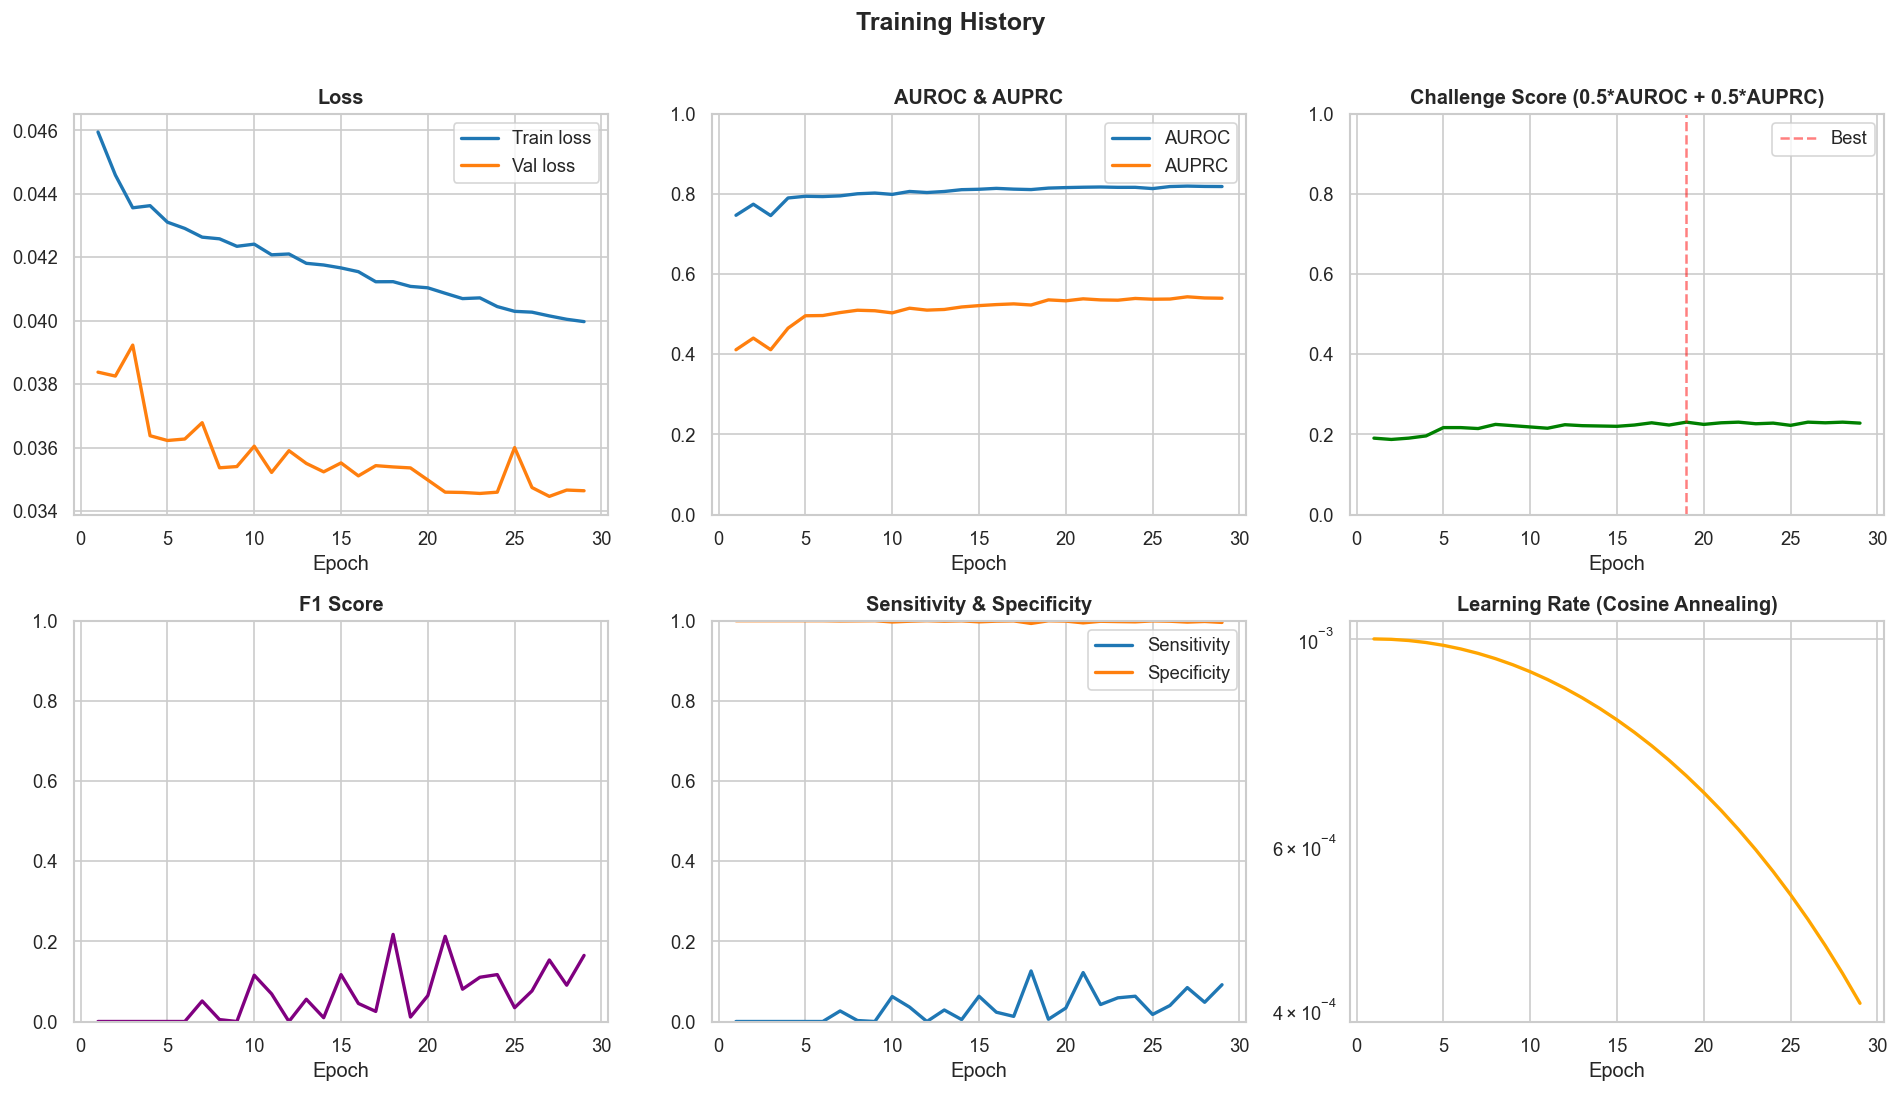

In [43]:
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

axes[0, 0].plot(hist_df["epoch"], hist_df["train_loss"], label="Train loss", linewidth=2)
axes[0, 0].plot(hist_df["epoch"], hist_df["val_loss"], label="Val loss", linewidth=2)
axes[0, 0].set_title("Loss", fontweight="bold")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].legend()

axes[0, 1].plot(hist_df["epoch"], hist_df["auroc"], label="AUROC", linewidth=2)
axes[0, 1].plot(hist_df["epoch"], hist_df["auprc"], label="AUPRC", linewidth=2)
axes[0, 1].set_title("AUROC & AUPRC", fontweight="bold")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].legend()

axes[0, 2].plot(hist_df["epoch"], hist_df["challenge_score"],
                linewidth=2, color="green")
best_idx = hist_df["challenge_score"].idxmax()
axes[0, 2].axvline(hist_df.loc[best_idx, "epoch"], linestyle="--",
                    color="red", alpha=0.5, label="Best")
axes[0, 2].set_title("Challenge Score (0.5*AUROC + 0.5*AUPRC)", fontweight="bold")
axes[0, 2].set_xlabel("Epoch")
axes[0, 2].set_ylim(0, 1)
axes[0, 2].legend()

axes[1, 0].plot(hist_df["epoch"], hist_df["f1"], linewidth=2, color="purple")
axes[1, 0].set_title("F1 Score", fontweight="bold")
axes[1, 0].set_xlabel("Epoch")
axes[1, 0].set_ylim(0, 1)

axes[1, 1].plot(hist_df["epoch"], hist_df["sensitivity"],
                label="Sensitivity", linewidth=2)
axes[1, 1].plot(hist_df["epoch"], hist_df["specificity"],
                label="Specificity", linewidth=2)
axes[1, 1].set_title("Sensitivity & Specificity", fontweight="bold")
axes[1, 1].set_xlabel("Epoch")
axes[1, 1].set_ylim(0, 1)
axes[1, 1].legend()

axes[1, 2].plot(hist_df["epoch"], hist_df["lr"], linewidth=2, color="orange")
axes[1, 2].set_title("Learning Rate (Cosine Annealing)", fontweight="bold")
axes[1, 2].set_xlabel("Epoch")
axes[1, 2].set_yscale("log")

fig.suptitle("Training History", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [44]:

ckpt_path = checkpoint_dir / "best_model.pt"
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt["model_state_dict"])
    print(f"Loaded best model from epoch {ckpt['epoch']} "
          f"(CS={ckpt['challenge_score']:.4f})")
else:
    print("No checkpoint found; using current model weights")

final_result, _, y_true_final, y_prob_final = validate(
    model, val_loader, criterion, device)

temp_scaler = TemperatureScaling()
learned_temp = temp_scaler.fit(model, val_loader, device)

model.eval()
all_logits_cal = []
with torch.no_grad():
    for signals, labels in val_loader:
        signals = signals.to(device)
        logits = model(signals)
        all_logits_cal.append(logits.cpu())
all_logits_cal = torch.cat(all_logits_cal)
y_prob_calibrated = torch.sigmoid(temp_scaler(all_logits_cal)).detach().numpy()

ece_raw = compute_ece(y_true_final, y_prob_final)
ece_calibrated = compute_ece(y_true_final, y_prob_calibrated)

opt_thr = find_optimal_threshold(y_true_final, y_prob_final, metric="f1")
opt_result = compute_metrics(y_true_final, y_prob_final, threshold=opt_thr)

opt_thr_cal = find_optimal_threshold(y_true_final, y_prob_calibrated, metric="f1")
opt_result_cal = compute_metrics(y_true_final, y_prob_calibrated, threshold=opt_thr_cal)

print(f"\n{'='*60}")
print(f"  FINAL EVALUATION RESULTS  (Validation Set)")
print(f"{'='*60}")
print(f"  AUROC           : {final_result.auroc:.4f}")
print(f"  AUPRC           : {final_result.auprc:.4f}")
print(f"  Challenge Score : {final_result.challenge_score:.4f}")
print(f"  F1 (thr=0.50)   : {final_result.f1:.4f}")
print(f"  Sensitivity     : {final_result.sensitivity:.4f}")
print(f"  Specificity     : {final_result.specificity:.4f}")
print(f"{'-'*60}")
print(f"  ECE (raw)       : {ece_raw:.4f}")
print(f"  ECE (calibrated): {ece_calibrated:.4f}")
print(f"  Temperature     : {learned_temp:.4f}")
print(f"{'-'*60}")
print(f"  Optimal threshold (F1): {opt_thr:.3f}")
print(f"  F1 (optimal)    : {opt_result.f1:.4f}")
print(f"  Sens (optimal)  : {opt_result.sensitivity:.4f}")
print(f"  Spec (optimal)  : {opt_result.specificity:.4f}")
print(f"{'-'*60}")
print(f"  CALIBRATED (optimal threshold: {opt_thr_cal:.3f})")
print(f"  F1 (cal)        : {opt_result_cal.f1:.4f}")
print(f"  Sens (cal)      : {opt_result_cal.sensitivity:.4f}")
print(f"  Spec (cal)      : {opt_result_cal.specificity:.4f}")
print(f"{'='*60}")

Loaded best model from epoch 19 (CS=0.2306)


Learned temperature: 1.4506

  FINAL EVALUATION RESULTS  (Validation Set)
  AUROC           : 0.8146
  AUPRC           : 0.5357
  Challenge Score : 0.2306
  F1 (thr=0.50)   : 0.0111
  Sensitivity     : 0.0056
  Specificity     : 0.9998
────────────────────────────────────────────────────────────
  ECE (raw)       : 0.1346
  ECE (calibrated): 0.1810
  Temperature     : 1.4506
────────────────────────────────────────────────────────────
  Optimal threshold (F1): 0.340
  F1 (optimal)    : 0.5181
  Sens (optimal)  : 0.6049
  Spec (optimal)  : 0.8540
────────────────────────────────────────────────────────────
  CALIBRATED (optimal threshold: 0.389)
  F1 (cal)        : 0.5137
  Sens (cal)      : 0.5890
  Spec (cal)      : 0.8593


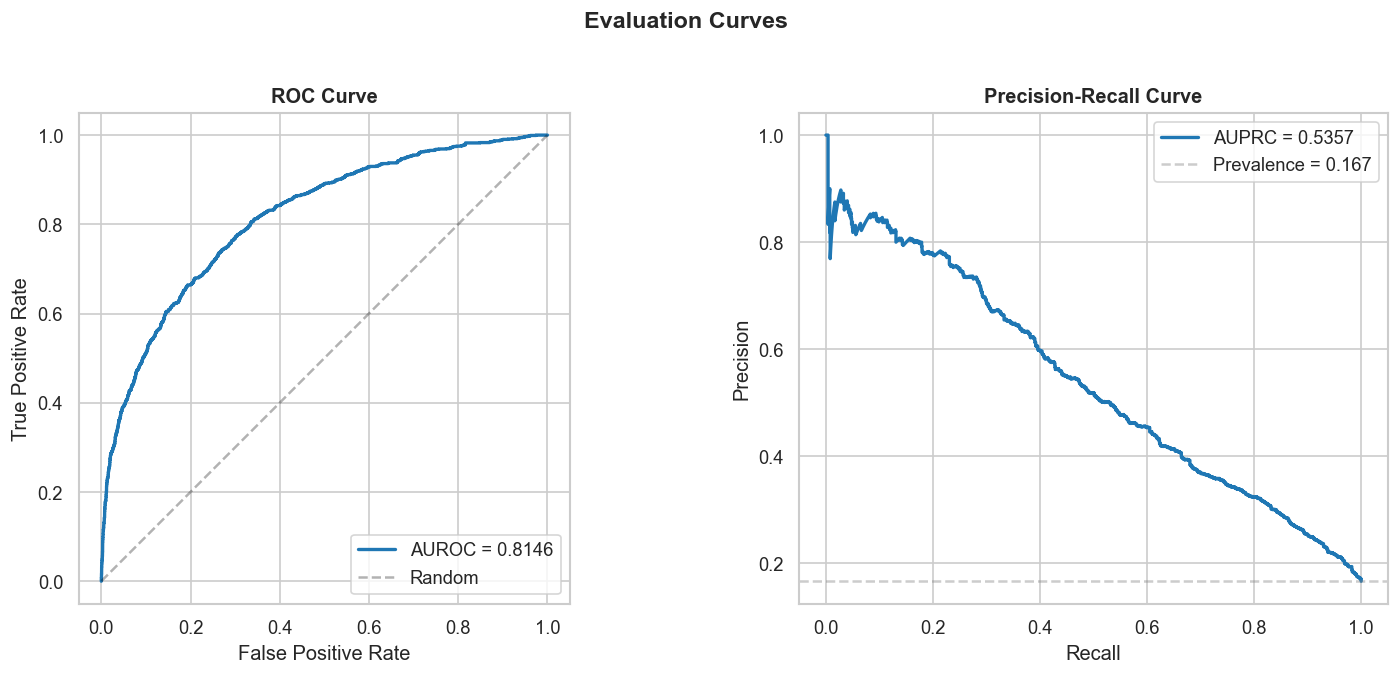

In [45]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

fpr, tpr, _ = roc_curve(y_true_final, y_prob_final)
axes[0].plot(fpr, tpr, linewidth=2,
             label=f"AUROC = {final_result.auroc:.4f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve", fontweight="bold")
axes[0].legend(loc="lower right", fontsize=11)
axes[0].set_aspect("equal")

precision, recall, _ = precision_recall_curve(y_true_final, y_prob_final)
prevalence = y_true_final.mean()
axes[1].plot(recall, precision, linewidth=2,
             label=f"AUPRC = {final_result.auprc:.4f}")
axes[1].axhline(prevalence, linestyle="--", color="gray", alpha=0.4,
                label=f"Prevalence = {prevalence:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve", fontweight="bold")
axes[1].legend(loc="upper right", fontsize=11)
axes[1].set_aspect("equal")

fig.suptitle("Evaluation Curves", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

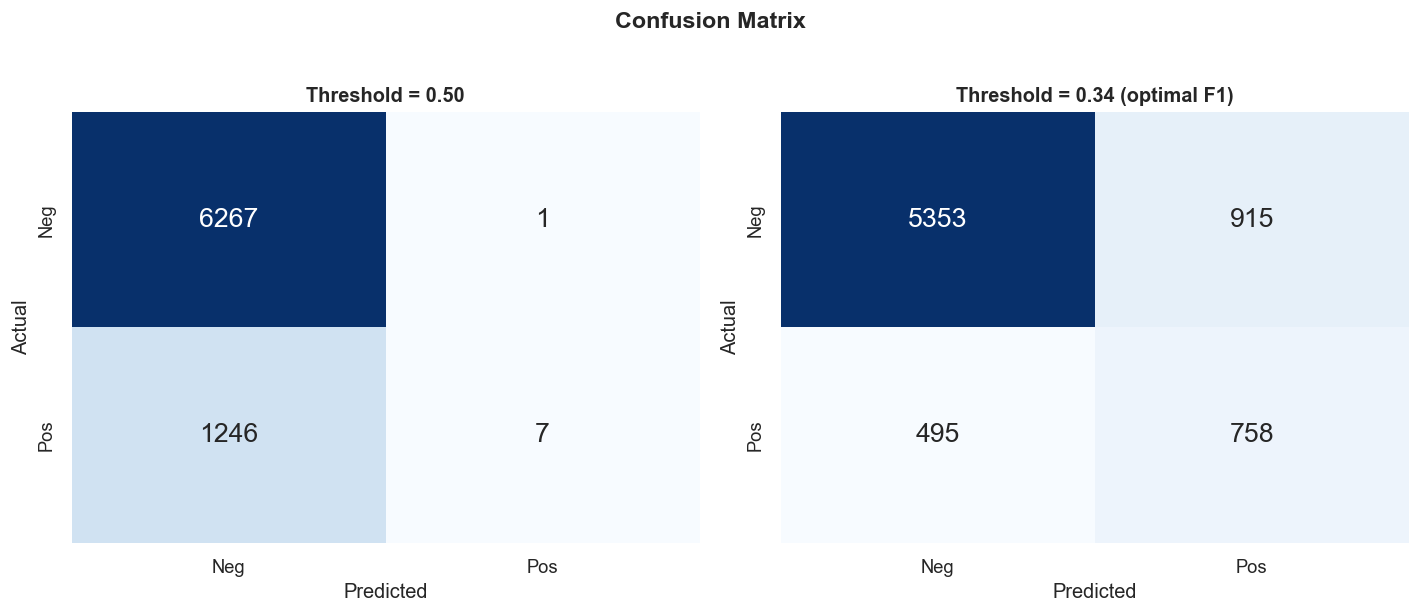

In [46]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, thr, title in [
    (axes[0], 0.5, f"Threshold = 0.50"),
    (axes[1], opt_thr, f"Threshold = {opt_thr:.2f} (optimal F1)"),
]:
    y_pred = (y_prob_final >= thr).astype(int)
    cm = confusion_matrix(y_true_final, y_pred, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Neg", "Pos"], yticklabels=["Neg", "Pos"],
                ax=ax, cbar=False, annot_kws={"size": 16})
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)
    ax.set_title(title, fontweight="bold")

fig.suptitle("Confusion Matrix", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

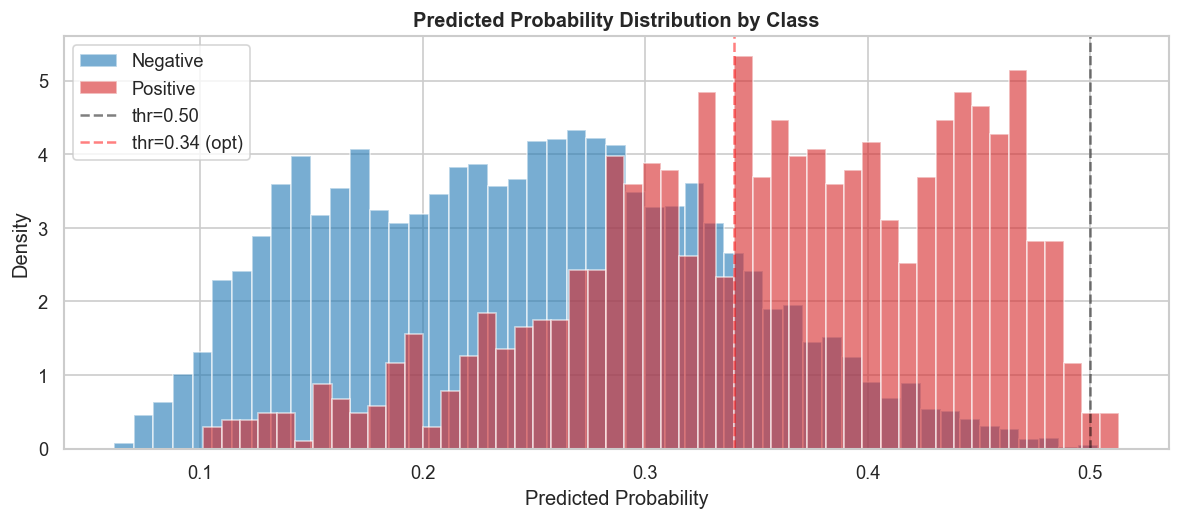

In [47]:

fig, ax = plt.subplots(1, 1, figsize=(10, 4.5))

ax.hist(y_prob_final[y_true_final == 0], bins=50, alpha=0.6,
        label="Negative", color=sns.color_palette()[0], density=True)
ax.hist(y_prob_final[y_true_final == 1], bins=50, alpha=0.6,
        label="Positive", color=sns.color_palette()[3], density=True)
ax.axvline(0.5, color="black", linestyle="--", alpha=0.5, label="thr=0.50")
ax.axvline(opt_thr, color="red", linestyle="--", alpha=0.5,
           label=f"thr={opt_thr:.2f} (opt)")
ax.set_xlabel("Predicted Probability", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Predicted Probability Distribution by Class", fontweight="bold")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [48]:

test_ds = CachedChagasDataset(cache_file, test_indices)
test_loader = DataLoader(
    test_ds, batch_size=CFG["batch_size"], shuffle=False,
    num_workers=CFG["num_workers"], pin_memory=use_pin_memory,
)

test_result, test_loss, y_true_test, y_prob_test = validate(model, test_loader, criterion, device)

all_logits_test = []
model.eval()
with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(device)
        logits = model(signals)
        all_logits_test.append(logits.cpu())
all_logits_test = torch.cat(all_logits_test)
y_prob_test_cal = torch.sigmoid(temp_scaler(all_logits_test)).detach().numpy()

ece_test_raw = compute_ece(y_true_test, y_prob_test)
ece_test_cal = compute_ece(y_true_test, y_prob_test_cal)

opt_thr_from_val = find_optimal_threshold(y_true_final, y_prob_final, metric="f1")
test_result_at_opt = compute_metrics(y_true_test, y_prob_test, threshold=opt_thr_from_val)

test_result_cal = compute_metrics(y_true_test, y_prob_test_cal, threshold=opt_thr_cal)

print(f"\n{'='*70}")
print(f"  Test set results")
print(f"{'='*70}")
print(f"  AUROC              : {test_result.auroc:.4f}")
print(f"  AUPRC              : {test_result.auprc:.4f}")
print(f"  Challenge Score    : {test_result.challenge_score:.4f}")
print(f"  ECE (raw)          : {ece_test_raw:.4f}")
print(f"  ECE (calibrated)   : {ece_test_cal:.4f}")
print(f"{'-'*70}")
print(f"  At threshold {opt_thr_from_val:.3f} (optimized on validation set):")
print(f"  F1 Score           : {test_result_at_opt.f1:.4f}")
print(f"  Sensitivity        : {test_result_at_opt.sensitivity:.4f}")
print(f"  Specificity        : {test_result_at_opt.specificity:.4f}")
print(f"{'-'*70}")
print(f"  CALIBRATED (threshold {opt_thr_cal:.3f} from validation):")
print(f"  F1 (cal)           : {test_result_cal.f1:.4f}")
print(f"  Sens (cal)         : {test_result_cal.sensitivity:.4f}")
print(f"  Spec (cal)         : {test_result_cal.specificity:.4f}")
print(f"{'='*70}")

print(f"\n  Val vs Test Comparison:")
print(f"  {'Metric':<20} {'Validation':>12} {'Test':>12} {'Delta':>10}")
print(f"  {'-'*54}")
print(f"  {'AUROC':<20} {final_result.auroc:>12.4f} {test_result.auroc:>12.4f} {test_result.auroc - final_result.auroc:>+10.4f}")
print(f"  {'AUPRC':<20} {final_result.auprc:>12.4f} {test_result.auprc:>12.4f} {test_result.auprc - final_result.auprc:>+10.4f}")
print(f"  {'Challenge Score':<20} {final_result.challenge_score:>12.4f} {test_result.challenge_score:>12.4f} {test_result.challenge_score - final_result.challenge_score:>+10.4f}")
print(f"  {'ECE':<20} {ece_raw:>12.4f} {ece_test_raw:>12.4f} {ece_test_raw - ece_raw:>+10.4f}")
print(f"  {'ECE (cal)':<20} {ece_calibrated:>12.4f} {ece_test_cal:>12.4f} {ece_test_cal - ece_calibrated:>+10.4f}")


  *** FINAL TEST SET RESULTS *** (Unbiased Performance Estimate)
  AUROC              : 0.8087
  AUPRC              : 0.5099
  Challenge Score    : 0.2164
  ECE (raw)          : 0.1314
  ECE (calibrated)   : 0.1775
──────────────────────────────────────────────────────────────────────
  At threshold 0.340 (optimized on validation set):
  F1 Score           : 0.5000
  Sensitivity        : 0.5883
  Specificity        : 0.8470
──────────────────────────────────────────────────────────────────────
  CALIBRATED (threshold 0.389 from validation):
  F1 (cal)           : 0.5023
  Sens (cal)         : 0.5826
  Spec (cal)         : 0.8525

  Val vs Test Comparison:
  Metric                 Validation         Test          Δ
  ------------------------------------------------------
  AUROC                      0.8146       0.8087    -0.0059
  AUPRC                      0.5357       0.5099    -0.0258
  Challenge Score            0.2306       0.2164    -0.0142
  ECE                        0.1346   


  SOURCE-STRATIFIED EVALUATION (Test Set)
  Threshold: 0.340 (optimized on validation set)
────────────────────────────────────────────────────────────────────────────────

  Source              N  Chagas+    Prev    AUROC    AUPRC     Sens     Spec
  ------------ -------- -------- ------- -------- -------- -------- --------
  code15          7,125      981  13.8%   0.8257   0.4896   0.6157   0.8470
  samitrop          248      248 100.0%      N/A      N/A   0.4798      N/A


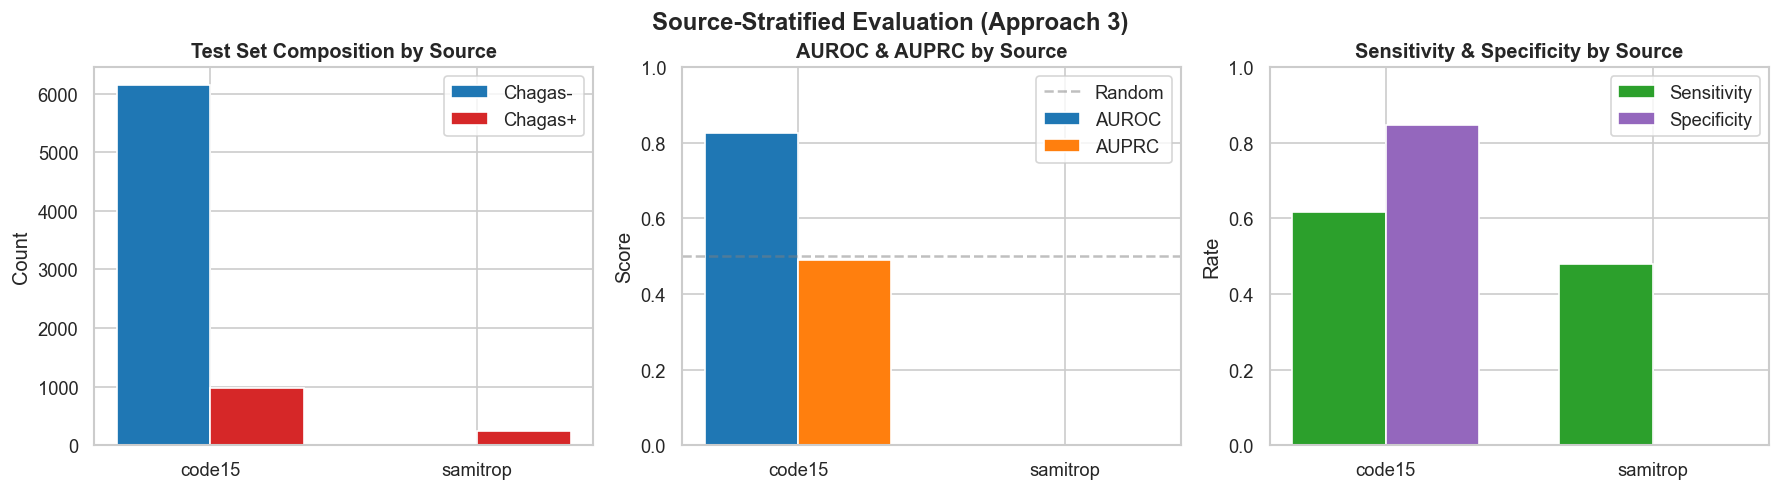


📊 SOURCE-STRATIFIED ANALYSIS:
  • code15: AUROC=0.826, AUPRC=0.490 (n=7,125, 13.8% Chagas+)
  • samitrop: 100% Chagas+ — only sensitivity computable (=0.480)


In [49]:

def evaluate_by_source(y_true, y_prob, sources, threshold=0.5):
    """Compute metrics stratified by data source."""
    results = {}
    unique_sources = np.unique(sources)
    
    for src in unique_sources:
        mask = sources == src
        n_samples = mask.sum()
        n_pos = y_true[mask].sum()
        
        if n_samples < 10:
            print(f"  {src}: Too few samples ({n_samples}), skipping")
            continue
        
        if n_pos > 0 and n_pos < n_samples:
            auroc = roc_auc_score(y_true[mask], y_prob[mask])
            auprc = average_precision_score(y_true[mask], y_prob[mask])
        else:
            auroc = np.nan
            auprc = np.nan
        
        y_pred = (y_prob[mask] >= threshold).astype(int)
        tn = ((y_true[mask] == 0) & (y_pred == 0)).sum()
        fp = ((y_true[mask] == 0) & (y_pred == 1)).sum()
        fn = ((y_true[mask] == 1) & (y_pred == 0)).sum()
        tp = ((y_true[mask] == 1) & (y_pred == 1)).sum()
        
        sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        spec = tn / (tn + fp) if (tn + fp) > 0 else np.nan
        
        results[src] = {
            "n_samples": int(n_samples),
            "n_pos": int(n_pos),
            "prevalence": float(n_pos / n_samples) if n_samples > 0 else 0,
            "auroc": float(auroc) if not np.isnan(auroc) else None,
            "auprc": float(auprc) if not np.isnan(auprc) else None,
            "sensitivity": float(sens) if not np.isnan(sens) else None,
            "specificity": float(spec) if not np.isnan(spec) else None,
        }
    
    return results

test_sources = test_meta["source"].values

print(f"\n{'='*80}")
print(f"  SOURCE-STRATIFIED EVALUATION (Test Set)")
print(f"{'='*80}")
print(f"  Threshold: {opt_thr_from_val:.3f} (optimized on validation set)")
print(f"{'-'*80}")

source_results = evaluate_by_source(y_true_test, y_prob_test, test_sources, threshold=opt_thr_from_val)

print(f"\n  {'Source':<12} {'N':>8} {'Chagas+':>8} {'Prev':>7} {'AUROC':>8} {'AUPRC':>8} {'Sens':>8} {'Spec':>8}")
print(f"  {'-'*12} {'-'*8} {'-'*8} {'-'*7} {'-'*8} {'-'*8} {'-'*8} {'-'*8}")

for src, res in source_results.items():
    auroc_str = f"{res['auroc']:.4f}" if res['auroc'] is not None else "N/A"
    auprc_str = f"{res['auprc']:.4f}" if res['auprc'] is not None else "N/A"
    sens_str = f"{res['sensitivity']:.4f}" if res['sensitivity'] is not None else "N/A"
    spec_str = f"{res['specificity']:.4f}" if res['specificity'] is not None else "N/A"
    
    print(f"  {src:<12} {res['n_samples']:>8,} {res['n_pos']:>8,} {res['prevalence']:>6.1%} "
          f"{auroc_str:>8} {auprc_str:>8} {sens_str:>8} {spec_str:>8}")

print(f"{'='*80}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sources_list = list(source_results.keys())
colors = sns.color_palette("Set2", len(sources_list))

ax = axes[0]
n_samples = [source_results[s]["n_samples"] for s in sources_list]
n_pos = [source_results[s]["n_pos"] for s in sources_list]
n_neg = [n - p for n, p in zip(n_samples, n_pos)]

x = np.arange(len(sources_list))
width = 0.35
ax.bar(x - width/2, n_neg, width, label="Chagas-", color=sns.color_palette()[0])
ax.bar(x + width/2, n_pos, width, label="Chagas+", color=sns.color_palette()[3])
ax.set_xticks(x)
ax.set_xticklabels(sources_list)
ax.set_ylabel("Count")
ax.set_title("Test Set Composition by Source", fontweight="bold")
ax.legend()

ax = axes[1]
aurocs = [source_results[s]["auroc"] if source_results[s]["auroc"] else 0 for s in sources_list]
auprcs = [source_results[s]["auprc"] if source_results[s]["auprc"] else 0 for s in sources_list]

x = np.arange(len(sources_list))
ax.bar(x - width/2, aurocs, width, label="AUROC", color=sns.color_palette()[0])
ax.bar(x + width/2, auprcs, width, label="AUPRC", color=sns.color_palette()[1])
ax.set_xticks(x)
ax.set_xticklabels(sources_list)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label="Random")
ax.set_title("AUROC & AUPRC by Source", fontweight="bold")
ax.legend()

ax = axes[2]
sens_vals = [source_results[s]["sensitivity"] if source_results[s]["sensitivity"] else 0 for s in sources_list]
spec_vals = [source_results[s]["specificity"] if source_results[s]["specificity"] else 0 for s in sources_list]

ax.bar(x - width/2, sens_vals, width, label="Sensitivity", color=sns.color_palette()[2])
ax.bar(x + width/2, spec_vals, width, label="Specificity", color=sns.color_palette()[4])
ax.set_xticks(x)
ax.set_xticklabels(sources_list)
ax.set_ylabel("Rate")
ax.set_ylim(0, 1)
ax.set_title("Sensitivity & Specificity by Source", fontweight="bold")
ax.legend()

plt.tight_layout()
plt.suptitle("Source-Stratified Evaluation (Approach 3)", fontweight="bold", y=1.02)
plt.show()

print("\nSource-stratified analysis:")
for src, res in source_results.items():
    if res["auroc"] is not None:
        print(f"  {src}: AUROC={res['auroc']:.3f}, AUPRC={res['auprc']:.3f} "
              f"(n={res['n_samples']:,}, {res['prevalence']:.1%} Chagas+)")
    else:
        if res["prevalence"] == 1.0:
            print(f"  {src}: 100% Chagas+; only sensitivity computable (={res['sensitivity']:.3f})")
        elif res["prevalence"] == 0.0:
            print(f"  {src}: 0% Chagas+; only specificity computable (={res['specificity']:.3f})")

In [50]:
def run_single_seed(seed, cfg, train_loader, val_loader, test_loader, device):
    """Train and evaluate a single seed. Returns dict of metrics."""
    torch.manual_seed(seed)
    np.random.seed(seed)
    
    model_s = ECGResNet(
        in_channels=cfg["in_channels"],
        base_filters=cfg["base_filters"],
        num_blocks_per_group=cfg["num_blocks_per_group"],
        kernel_size=cfg["kernel_size"],
        dropout=cfg["dropout"],
    ).to(device)
    
    criterion_s, loss_name_s = build_criterion(cfg, device)
    optimiser_s = AdamW(model_s.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    scheduler_s = CosineAnnealingLR(optimiser_s, T_max=cfg["epochs"])
    early_stop_s = EarlyStopping(patience=cfg["patience"])
    
    ckpt_dir = Path(cfg["checkpoint_dir"])
    ckpt_dir.mkdir(parents=True, exist_ok=True)
    ckpt_path = ckpt_dir / f"best_model_seed{seed}.pt"
    
    best_cs = -1.0
    print(f"\n{'='*50}")
    print(f"  SEED {seed}")
    print(f"{'='*50}")
    
    for epoch in range(1, cfg["epochs"] + 1):
        t0 = time.time()
        train_loss = train_one_epoch(
            model_s, train_loader, criterion_s, optimiser_s, device,
            epoch=epoch, total_epochs=cfg["epochs"],
            label_smoothing=cfg.get("label_smoothing", 0.0),
        )
        val_res, val_loss, _, _ = validate(model_s, val_loader, criterion_s, device)
        elapsed = time.time() - t0
        
        if val_res.challenge_score > best_cs:
            best_cs = val_res.challenge_score
            torch.save({"model_state_dict": model_s.state_dict(), "epoch": epoch}, ckpt_path)
            marker = " *"
        else:
            marker = ""
        
        if epoch % 5 == 0 or epoch == 1:
            print(f"  Ep {epoch:3d} | CS={val_res.challenge_score:.4f} | "
                  f"AUROC={val_res.auroc:.4f} | AUPRC={val_res.auprc:.4f} | "
                  f"{elapsed:.0f}s{marker}")
        
        scheduler_s.step()
        torch.save({"model_state_dict": model_s.state_dict(), "epoch": epoch}, ckpt_dir / f"model_seed{seed}_epoch_{epoch}.pt")

        if early_stop_s(val_res.challenge_score):
            print(f"  Early stopping at epoch {epoch}")
            break
    
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model_s.load_state_dict(ckpt["model_state_dict"])
    
    val_result, _, y_true_v, y_prob_v = validate(model_s, val_loader, criterion_s, device)
    test_result, _, y_true_t, y_prob_t = validate(model_s, test_loader, criterion_s, device)
    
    ts = TemperatureScaling()
    temp = ts.fit(model_s, val_loader, device)
    
    ece_val = compute_ece(y_true_v, y_prob_v)
    ece_test = compute_ece(y_true_t, y_prob_t)
    
    opt_thr = find_optimal_threshold(y_true_v, y_prob_v, metric="f1")
    test_at_opt = compute_metrics(y_true_t, y_prob_t, threshold=opt_thr)
    
    return {
        "seed": seed,
        "val_auroc": val_result.auroc,
        "val_auprc": val_result.auprc,
        "val_cs": val_result.challenge_score,
        "val_ece": ece_val,
        "test_auroc": test_result.auroc,
        "test_auprc": test_result.auprc,
        "test_cs": test_result.challenge_score,
        "test_ece": ece_test,
        "test_f1": test_at_opt.f1,
        "test_sens": test_at_opt.sensitivity,
        "test_spec": test_at_opt.specificity,
        "opt_threshold": opt_thr,
        "temperature": temp,
    }

✓ run_single_seed() defined.


In [51]:

if 'test_loader' not in dir():
    test_ds = CachedChagasDataset(cache_file, test_indices)
    test_loader = DataLoader(
        test_ds, batch_size=CFG["batch_size"], shuffle=False,
        num_workers=CFG["num_workers"], pin_memory=use_pin_memory,
    )

all_seed_results = []
for seed in CFG["seeds"]:
    result = run_single_seed(seed, CFG, train_loader, val_loader, test_loader, device)
    all_seed_results.append(result)

seed_df = pd.DataFrame(all_seed_results)

print(f"\n{'='*70}")
print(f"  MULTI-SEED RESULTS ({len(CFG['seeds'])} seeds)")
print(f"{'='*70}")

metrics = ["val_auroc", "val_auprc", "val_cs", "val_ece",
           "test_auroc", "test_auprc", "test_cs", "test_ece",
           "test_f1", "test_sens", "test_spec", "opt_threshold", "temperature"]

for m in metrics:
    vals = seed_df[m].values
    print(f"  {m:<16}: {vals.mean():.4f} ± {vals.std():.4f}  ({', '.join(f'{v:.4f}' for v in vals)})")

print(f"{'='*70}")
print(f"\n  Seeds used: {CFG['seeds']}")
print(f"  Best test CS: seed {seed_df.loc[seed_df['test_cs'].idxmax(), 'seed']:.0f} "
      f"({seed_df['test_cs'].max():.4f})")

seed_df


  SEED 42


  Ep   1 | CS=0.1804 | AUROC=0.7736 | AUPRC=0.4263 | 361s *


  Ep   5 | CS=0.2195 | AUROC=0.7999 | AUPRC=0.4979 | 374s *


  Ep  10 | CS=0.2187 | AUROC=0.8075 | AUPRC=0.5052 | 375s


  Ep  15 | CS=0.2203 | AUROC=0.8214 | AUPRC=0.5261 | 381s


KeyboardInterrupt: 